# Modelo Mensual — V30 (HailMary Final)
## Ens_Segmentado + V23 Innovations + SIGEX/SEIA + Bias Correction + Segment-Aware Grid

### Architecture
- **Segmentation**: SmallMed (Mine_Size ≤ 1) vs LargeColossal (Mine_Size ≥ 2), rolling 12m quartile.
- **Target**: LogRatio = log(Prod_h / Prod_origin), clipped [−1.5, 1.5].
- **Stat anchors**: ARIMA(1,1,1) + SARIMAX(1,1,1)(1,0,1,12) + RollingMean-36m.
- **Bias correction**: Walk-forward per-mine × per-horizon (past origins only — no leakage).
- **Ensemble grid**: 540 combos — α_sm_short/α_sm_long (SM) × α_lc (LC) × 3 stat models.
- **Optuna**: 100 trials × 6 studies (LGB_SM, LGB_LC, RF_SM, RF_LC + XGB if installed).
- **Features SM (29)**: BASE-17 + Shock_Intensity, Pandemic_Lag1, SIGEX_Cu_InEval, Friction, Has_Desal, Cu_Price_Lag12, Cu_Price_Mom6, Is_Porphyry, Is_Oxide, Is_CODELCO, Reserve_Life, Horizonte_feat.
- **Features LC (31)**: BASE-17 + Shock_Intensity, SIGEX_Cu_Total, SIGEX_Cu_InEval, SEIA_Inv_Active, Inv_Lag_48, Capital_Stock, Has_Desal, Cu_Price_Lag12, Cu_Price_Mom6, Is_Porphyry, Is_Oxide, Is_CODELCO, Reserve_Life, Horizonte_feat.

### Results (updated after run)
| Metric | Value |
|--------|-------|
| MAPE   | — |
| Skill  | — |
| WR%    | — |
| Hfoc   | — |
| Minas_50 | — |


In [1]:
# ── 0. Variable Check — verify all inputs before running ───────────────────────
import pandas as pd
import numpy as np
import os

MASTER_PATH = '../../01_Data/processed/1_master_thesis_data.csv'
SEIA_PATH   = '../../01_Data/raw/Proyectos_SEIA.xlsx'
SIGEX_PATH  = '../../02_Clustering/sigex_clustering/outputs/sigex_clusters.csv'

CHECKS = {}
if os.path.exists(MASTER_PATH):
    df_check = pd.read_csv(MASTER_PATH, nrows=10)
    for col in ['Date','Match_Key','Production','Cu_Price','Capital_Stock',
                'Has_Desal','Has_Energy','Inv_Lag_48']:
        CHECKS[f'master.{col}'] = '✓' if col in df_check.columns else '✗ MISSING'
else:
    CHECKS['master_file'] = '✗ FILE NOT FOUND'

if os.path.exists(SEIA_PATH):
    sc = pd.read_excel(SEIA_PATH, nrows=3)
    for col in ['Titular','Estado del Proyecto','Fecha Presentación','Inversión (MMU$)']:
        CHECKS[f'seia.{col}'] = '✓' if col in sc.columns else '✗ MISSING'
else:
    CHECKS['seia_file'] = '✗ FILE NOT FOUND'

if os.path.exists(SIGEX_PATH):
    gc = pd.read_csv(SIGEX_PATH, nrows=3)
    for col in ['Region_Norm','Recurso_Grupo','Estado','Cluster']:
        CHECKS[f'sigex.{col}'] = '✓' if col in gc.columns else '✗ MISSING'
else:
    CHECKS['sigex_file'] = '✗ FILE NOT FOUND'

all_ok = True
print('── Variable Check ──────────────────────────────────')
for k, v in CHECKS.items():
    print(f'  {v}  {k}' + (' ← FIX BEFORE RUNNING' if '✗' in v else ''))
    if '✗' in v: all_ok = False
print('────────────────────────────────────────────────────')
print('All checks passed ✓' if all_ok else '⚠  Fix issues above before continuing.')

── Variable Check ──────────────────────────────────
  ✓  master.Date
  ✓  master.Match_Key
  ✓  master.Production
  ✓  master.Cu_Price
  ✓  master.Capital_Stock
  ✓  master.Has_Desal
  ✓  master.Has_Energy
  ✓  master.Inv_Lag_48
  ✓  seia.Titular
  ✓  seia.Estado del Proyecto
  ✓  seia.Fecha Presentación
  ✓  seia.Inversión (MMU$)
  ✓  sigex.Region_Norm
  ✓  sigex.Recurso_Grupo
  ✓  sigex.Estado
  ✓  sigex.Cluster
────────────────────────────────────────────────────
All checks passed ✓


In [2]:
# ── 1. Setup ───────────────────────────────────────────────────────────────────
import warnings
import json
from tqdm import tqdm
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost:', xgb.__version__)
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed (pip install xgboost) — XGB combos skipped')

warnings.filterwarnings('ignore')

HORIZONS        = [6, 9, 12, 18, 24, 30, 36, 42, 48, 54, 60]  # H+1 dropped: too noisy / marginal vs naive
H_SHORT         = [1, 3, 6, 9, 12]
H_MID           = [18]
H_LONG          = [24, 30, 36, 42, 48, 54, 60]
H_FOCUS         = [36, 48, 60]
# V33: val semiannual 2018-01→2020-07, test desplazado 3m: 2020-10 y 2021-04
# H+60 desde 2020-10 cae en 2025-10 (dentro del dato); 2021-04+H60=2026-04 (parcial)
_VAL_DATES      = pd.date_range('2018-01-01', '2020-07-01', freq='6MS').tolist()
_TST_DATES      = [pd.Timestamp('2020-10-01'), pd.Timestamp('2021-04-01')]
ROLLING_ORIGINS = _VAL_DATES + _TST_DATES  # 8 origins total
TEST_ORIGINS    = {pd.Timestamp('2020-10-01'), pd.Timestamp('2021-04-01')}
# VAL:  6 origins (2018-01 to 2020-07) — grid search + ensemble selection here only (no leakage)
# TEST: 2 origins (2020-10, 2021-04) — desplazados 3m para incluir H+60
# Temporal overlap is intentional: last val H+48 → 2024-07 = test 2022-07 H+24
#   This avoids wasting target-period data while keeping strict model-selection hygiene.
PANDEMIC_START  = pd.Timestamp('2020-03-01')
PANDEMIC_END    = pd.Timestamp('2021-12-31')
RECOVERY_START  = pd.Timestamp('2022-01-01')
RECOVERY_END    = pd.Timestamp('2023-12-31')
EXCLUDE_MINES   = {'haldeman','altos de punitaqui','tres valles',
                   'pampa camarones','michilla','quebrada blanca','spence','cerro negro'}
ZOMBIE_MINES    = {'cerro colorado','salvador'}
EXPORT_DIR      = 'outputs_hail_mary_v35'
os.makedirs(EXPORT_DIR, exist_ok=True)

LGB_PARAMS_SM = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
                     min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                     objective='huber', alpha=0.9, verbose=-1, n_jobs=-1, random_state=42)
LGB_PARAMS_LC = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
                     min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                     objective='regression', verbose=-1, n_jobs=-1, random_state=42)
RF_PARAMS     = dict(n_estimators=300, max_depth=12, min_samples_leaf=3,
                     max_features=0.5, n_jobs=-1, random_state=42)
XGB_PARAMS_SM = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     objective='reg:pseudohubererror', verbosity=0, random_state=42)
XGB_PARAMS_LC = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     objective='reg:squarederror', verbosity=0, random_state=42)

n_val  = sum(1 for o in ROLLING_ORIGINS if o not in TEST_ORIGINS)
print(f'Origins: {len(ROLLING_ORIGINS)} total | VAL: {n_val} | TEST: {len(TEST_ORIGINS)}')
print(f'Horizons: {HORIZONS}')


XGBoost: 3.1.3
Origins: 8 total | VAL: 6 | TEST: 2
Horizons: [6, 9, 12, 18, 24, 30, 36, 42, 48, 54, 60]


In [3]:
# ── 2. Data Load ───────────────────────────────────────────────────────────────
df_raw = pd.read_csv(MASTER_PATH)
df_raw['Date']      = pd.to_datetime(df_raw['Date'])
df_raw['Match_Key'] = df_raw['Match_Key'].str.lower().str.strip()
# Re-split Centinela: óxidos and súlfuros share the same Match_Key in master → fix
df_raw.loc[df_raw['Mine'].str.contains('xido',  na=False), 'Match_Key'] = 'centinela_oxidos'
df_raw.loc[df_raw['Mine'].str.contains('lfuro', na=False), 'Match_Key'] = 'centinela_sulfuros'
if 'Inversión (MMU$)' in df_raw.columns:
    df_raw.rename(columns={'Inversión (MMU$)': 'Inversion'}, inplace=True)
df_raw['Production']    = df_raw['Production'].fillna(0).clip(lower=0)
df_raw['Capital_Stock'] = df_raw['Capital_Stock'].fillna(0)
df_raw['Inv_Lag_48']    = df_raw['Inv_Lag_48'].fillna(0)
df_raw['Has_Desal']     = df_raw['Has_Desal'].fillna(0)
df_raw['Has_Energy']    = df_raw['Has_Energy'].fillna(0)
df_raw['Cu_Price']      = df_raw['Cu_Price'].ffill()
df_raw = df_raw[~df_raw['Match_Key'].isin(EXCLUDE_MINES)].reset_index(drop=True)
df_raw = df_raw.sort_values(['Match_Key','Date']).reset_index(drop=True)
MINES = sorted(df_raw['Match_Key'].unique().tolist())
print(f'Mines: {len(MINES)} | Range: {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}')
print(f'Has_Desal: {df_raw["Has_Desal"].mean():.1%} | '
      f'Has_Energy: {df_raw["Has_Energy"].mean():.1%} | '
      f'Inv_Lag_48 non-zero: {(df_raw["Inv_Lag_48"]>0).mean():.1%}')

# ── 3. SEIA time-varying features ──────────────────────────────────────────────
SEIA_MAPPING = {
    'minera escondida limitada':'escondida','minera centinela.':'centinela_sulfuros',
    'minera los pelambres':'los pelambres','codelco chile división andina':'andina',
    'codelco chile división salvador':'salvador',
    'codelco chile, división chuquicamata':'chuquicamata',
    'codelco chile división el teniente':'el teniente',
    'codelco chile, división radomiro tomic':'radomiro tomic',
    'división ministro hales de codelco chile':'ministro hales',
    'compañía doña inés de collahuasi scm':'collahuasi',
    'compañía minera doña inés de collahuasi scm':'collahuasi',
    'anglo american sur s.a':'los bronces','sierra gorda s.c.m.':'sierra gorda',
    'minera candelaria':'candelaria','minera antucoya':'antucoya',
    'minera zaldivar':'zaldivar','minera caserones':'caserones',
    'compañía minera del pacífico s.a.':'otros','empresa nacional de minería':'otros',
}
seia_cache = {}
try:
    seia = pd.read_excel(SEIA_PATH)
    seia['Fecha_Pres'] = pd.to_datetime(seia['Fecha Presentación'], errors='coerce')
    seia['Fecha_Cal']  = pd.to_datetime(seia['Fecha Calificación'],  errors='coerce')
    seia['Mine_Key']   = seia['Titular'].str.lower().str.strip().map(SEIA_MAPPING)
    seia['Inv_MMU']    = pd.to_numeric(seia['Inversión (MMU$)'], errors='coerce').fillna(0)
    seia['Approved']   = (seia['Estado del Proyecto']=='Aprobado').astype(int)
    sm = seia[seia['Mine_Key'].notna()].copy()
    for od in ROLLING_ORIGINS:
        for mine in MINES:
            sub = sm[(sm['Mine_Key']==mine)&(sm['Fecha_Pres']<od)]
            if len(sub)==0: seia_cache[(mine,od)]=(0.5,0.0); continue
            friction = sub['Approved'].mean()
            active   = sub[(sub['Approved']==0)&(sub['Fecha_Cal'].isna()|(sub['Fecha_Cal']>=od))]
            seia_cache[(mine,od)] = (friction, np.log1p(active['Inv_MMU'].sum()))
    print(f'SEIA cache: {len(seia_cache)} entries ✓')
except Exception as e:
    print(f'SEIA fallback: {e}')
    for od in ROLLING_ORIGINS:
        for mine in MINES: seia_cache[(mine,od)]=(0.5,0.0)

# ── 4. SIGEX static features ───────────────────────────────────────────────────
MINE_REGION = {
    'escondida':'ANTOFAGASTA','collahuasi':'TARAPACÁ','el teniente':"O'HIGGINS",
    'los pelambres':'COQUIMBO','chuquicamata':'ANTOFAGASTA','radomiro tomic':'ANTOFAGASTA',
    'los bronces':'REGIÓN METROPOLITANA','andina':'VALPARAÍSO','ministro hales':'ANTOFAGASTA',
    'candelaria':'ATACAMA','sierra gorda':'ANTOFAGASTA','centinela_oxidos':'ANTOFAGASTA','centinela_sulfuros':'ANTOFAGASTA',
    'caserones':'ATACAMA','gabriela mistral':'ANTOFAGASTA','el abra':'ANTOFAGASTA',
    'zaldivar':'ANTOFAGASTA','lomas bayas':'ANTOFAGASTA','antucoya':'ANTOFAGASTA',
    'andacollo':'COQUIMBO','cerro colorado':'TARAPACÁ','mantoverde':'ATACAMA',
    'mantos blancos':'ANTOFAGASTA','salvador':'ATACAMA','el soldado':'VALPARAÍSO',
    'ojos del salado':'ATACAMA','franke':'ANTOFAGASTA','atacama kozan':'ATACAMA','otros':'ANTOFAGASTA'
}
try:
    sigex = pd.read_csv(SIGEX_PATH)
    cu    = sigex[sigex['Recurso_Grupo']=='Cobre']
    r_tot  = cu.groupby('Region_Norm').size().to_dict()
    r_eval = cu[cu['Estado']=='Proyecto en Evaluación'].groupby('Region_Norm').size().to_dict()
    c_sz   = cu[cu['Cluster']>=0].groupby('Cluster').size().to_dict()
    mx_t,mx_e,mx_c = max(r_tot.values()),max(r_eval.values() or [1]),max(c_sz.values() or [1])
    def sfeat(mine):
        r = MINE_REGION.get(mine,'ANTOFAGASTA')
        rc = cu[(cu['Region_Norm']==r)&(cu['Cluster']>=0)]
        top = rc['Cluster'].mode().iloc[0] if len(rc) else -1
        return (r_tot.get(r,0)/mx_t, r_eval.get(r,0)/mx_e,
                c_sz.get(top,0)/mx_c, sigex[sigex['Region_Norm']==r].shape[0]/len(sigex))
    sf = {m: sfeat(m) for m in MINES}
    for col,i in [('SIGEX_Cu_Total',0),('SIGEX_Cu_InEval',1),('SIGEX_Cluster_Cu',2),('Reg_Vit',3)]:
        df_raw[col] = df_raw['Match_Key'].map({m:v[i] for m,v in sf.items()}).fillna(0)
    print('SIGEX features ✓')
except Exception as e:
    print(f'SIGEX fallback: {e}')
    for col in ['SIGEX_Cu_Total','SIGEX_Cu_InEval','SIGEX_Cluster_Cu','Reg_Vit']: df_raw[col]=0.0

# ── 5. Shock_Intensity ─────────────────────────────────────────────────────────
nat = df_raw.groupby('Date')['Production'].sum().reset_index()
nat['MA60'] = nat['Production'].rolling(60,min_periods=12).mean().bfill()
df_raw = df_raw.merge(nat[['Date','Production','MA60']].rename(
    columns={'Production':'Nat_Prod','MA60':'Nat_MA60'}), on='Date', how='left')
df_raw['Shock_Intensity'] = (df_raw['Nat_Prod']/df_raw['Nat_MA60'].clip(lower=1)).clip(0.5,1.5)
print('Data ready:', df_raw.shape)

# ── 6. Static lookup features ─────────────────────────────────────────────────
# Deposit type — Is_Porphyry (Pórfido vs IOCG/Estratoligado)
try:
    dep_df = pd.read_csv('../../../Estudio/depositos.csv')
    dep_df['mk'] = dep_df['Nombre_Deposito'].str.lower().str.strip()
    porphyry_map = dep_df.set_index('mk')['Modelo_Deposito'].apply(
        lambda x: 1 if isinstance(x, str) and 'pórfido' in x.lower() else 0).to_dict()
    df_raw['Is_Porphyry'] = df_raw['Match_Key'].map(porphyry_map).fillna(1).astype(int)
    print(f'Is_Porphyry: {df_raw["Is_Porphyry"].mean():.1%} porphyry')
except Exception as e:
    print(f'Is_Porphyry fallback: {e}'); df_raw['Is_Porphyry'] = 1

# Mine type + ownership — Is_Oxide, Is_CODELCO
try:
    meta_df = pd.read_csv('../../01_Data/processed/metadata_minas.csv')
    meta_df['mk'] = meta_df['Mine'].str.lower().str.strip()
    oxide_m   = meta_df.set_index('mk')['Type'].apply(lambda x: 1 if x in ['Oxidos','Mixto'] else 0).to_dict()
    codelco_m = meta_df.set_index('mk')['Owner'].apply(lambda x: 1 if x == 'CODELCO' else 0).to_dict()
    df_raw['Is_Oxide']   = df_raw['Match_Key'].map(oxide_m).fillna(0).astype(int)
    df_raw['Is_CODELCO'] = df_raw['Match_Key'].map(codelco_m).fillna(0).astype(int)
    # Centinela split overrides (metadata only has merged key)
    df_raw.loc[df_raw['Match_Key']=='centinela_oxidos',   'Is_Oxide'] = 1
    df_raw.loc[df_raw['Match_Key']=='centinela_sulfuros', 'Is_Oxide'] = 0
    print(f'Is_Oxide: {df_raw["Is_Oxide"].mean():.1%} oxide/mixto  |  Is_CODELCO: {df_raw["Is_CODELCO"].mean():.1%} state-owned')
except Exception as e:
    print(f'Is_Oxide/Is_CODELCO fallback: {e}'); df_raw['Is_Oxide'] = 0; df_raw['Is_CODELCO'] = 0

# Reserve life map — total Cu tonnes per mine (static snapshot)
try:
    rr_df = pd.read_csv('../../../Estudio/recursos_reservas.csv')
    reserves_map = rr_df[rr_df['Mineral'] == 'Cobre'].groupby(
        rr_df['Nombre_Deposito'].str.lower().str.strip())['Contenido_Metalico_T'].sum().to_dict()
    print(f'reserves_map: {len(reserves_map)} mines loaded')
except Exception as e:
    print(f'reserves_map fallback: {e}'); reserves_map = {}


# ── 7. Owner company stock prices (monthly close, direct ownership only) ─
STOCK_PATH  = '../../01_Data/processed/owner_stock_prices.csv'
TICKER_PATH = '../../01_Data/processed/mine_ticker_map.json'
try:
    _sdf        = pd.read_csv(STOCK_PATH, parse_dates=['Date'])
    _mine_ticker = json.load(open(TICKER_PATH))
    _stock_wide  = _sdf.pivot(index='Date', columns='Ticker', values='Close')
    # Log-price per mine (direct owner only; CODELCO/no-owner → 0)
    mine_stock_level = {}
    for _mine, _ticker in _mine_ticker.items():
        s = np.log(_stock_wide[_ticker].clip(lower=0.01))
        mine_stock_level[_mine] = s
    print(f'Stock levels loaded: {len(mine_stock_level)} mines with direct owner')
    # USD/CLP exchange rate (separate macro feature for all mines)
    _clp = _sdf[_sdf['Ticker']=='CLP=X'].set_index('Date')['Close']
    usd_clp_series = np.log(_clp.clip(lower=1))  # log-level
    print(f'USD/CLP loaded: {len(usd_clp_series)} months')
except Exception as e:
    print(f'Stock fallback: {e}'); mine_stock_level = {}


Mines: 29 | Range: 2014-01-01 → 2026-03-01
Has_Desal: 6.3% | Has_Energy: 23.5% | Inv_Lag_48 non-zero: 1.9%
SEIA cache: 232 entries ✓
SIGEX features ✓
Data ready: (4260, 17)
Is_Porphyry: 82.7% porphyry
Is_Oxide: 41.4% oxide/mixto  |  Is_CODELCO: 0.0% state-owned
reserves_map: 99 mines loaded
Stock levels loaded: 28 mines with direct owner
USD/CLP loaded: 156 months


In [4]:
# ── 3. Feature Engineering ──────────────────────────────────────────────────────
COMPANY_SIZE_MAP = {
    'escondida':2,'chuquicamata':2,'el teniente':2,'andina':2,'radomiro tomic':2,
    'salvador':2,'ministro hales':2,'gabriela mistral':2,'collahuasi':2,
    'los bronces':2,'lomas bayas':2,'cerro colorado':2,'el abra':2,
    'los pelambres':1,'centinela':1,'zaldivar':1,'antucoya':1,'andacollo':1,
    'candelaria':1,'caserones':1,'sierra gorda':1,'mantoverde':1,'mantos blancos':1,
    'ojos del salado':1,'atacama kozan':0,'franke':0,'el soldado':0,'otros':0
}

def compute_mine_size(df, origin_date):
    end = origin_date - pd.DateOffset(months=1)
    start = origin_date - pd.DateOffset(months=13)
    avgs = {m: (df[(df['Match_Key']==m)&(df['Date']>=start)&(df['Date']<=end)]['Production'].mean() or 0.0)
            for m in MINES}
    vals = list(avgs.values())
    q25,q50,q75 = np.percentile(vals,25),np.percentile(vals,50),np.percentile(vals,75)
    return {m:(0 if v<=q25 else 1 if v<=q50 else 2 if v<=q75 else 3) for m,v in avgs.items()}

def build_features(df, ms_map, origin_date):
    df = df[df['Date']<=origin_date].copy().sort_values(['Match_Key','Date'])
    g  = df.groupby('Match_Key')
    df['Prod_Lag1']  = g['Production'].shift(1)
    df['Prod_Lag12'] = g['Production'].shift(12)
    df['Prod_MA12']  = g['Production'].transform(lambda x: x.shift(1).rolling(12,min_periods=3).mean())
    df['Tendencia_12m'] = g['Production'].transform(
        lambda x: x.shift(1).rolling(12,min_periods=6).apply(
            lambda v: np.polyfit(range(len(v)),v,1)[0] if len(v)>=6 else 0, raw=True))
    df['Mine_trend_slope_36m'] = g['Production'].transform(
        lambda x: x.shift(1).rolling(36,min_periods=12).apply(
            lambda v: np.polyfit(range(len(v)),v,1)[0] if len(v)>=12 else 0, raw=True))
    df['Prod_pct_change_m']   = g['Production'].pct_change(1).fillna(0).clip(-2,2)
    df['Prod_pct_change_36m'] = g['Production'].pct_change(36).fillna(0).clip(-2,2)
    df['Month']        = df['Date'].dt.month
    df['Month_sin']    = np.sin(2*np.pi*df['Month']/12)
    df['Month_cos']    = np.cos(2*np.pi*df['Month']/12)
    df['Mine_age']     = g['Production'].transform(lambda x: ((x>0).cumsum()).clip(upper=36))
    df['Mine_Size']    = df['Match_Key'].map(ms_map).fillna(0)
    df['Company_Size'] = df['Match_Key'].map(COMPANY_SIZE_MAP).fillna(0)
    df['Mine_share']   = df['Production']/(df.groupby('Date')['Production'].transform('sum')+1e-6)
    cu_med             = df['Cu_Price'].rolling(24,min_periods=6).median()
    df['Cu_regime']    = (df['Cu_Price']>cu_med).astype(int)
    # Peak_Prod safe: build_features pre-filters Date<=origin_date (line 20), so no look-ahead
    df['Peak_Prod']    = g['Production'].transform(lambda x: x.expanding().max())
    df['Prod_vs_peak'] = df['Production']/(df['Peak_Prod']+1e-6)
    df['Is_RampUp']    = (df['Production']>g['Production'].shift(1)).astype(int)
    df['Is_Decline']   = (df['Prod_pct_change_36m']<-0.15).astype(int)
    df['Is_Terminal_Decline'] = ((df['Prod_vs_peak'] < 0.30) & (df['Tendencia_12m'] < 0)).astype(int)
    df['Is_Pandemic_Orig'] = ((df['Date']>=PANDEMIC_START)&(df['Date']<=PANDEMIC_END)).astype(int)
    df['Pandemic_Lag1']    = df['Is_Pandemic_Orig']*df['Prod_Lag1'].fillna(0)
    # Cu_Price time-series features (same across mines per date)
    df_cu = df.drop_duplicates('Date').sort_values('Date')[['Date','Cu_Price']].copy()
    df_cu['Cu_Price_Lag12'] = df_cu['Cu_Price'].shift(12).ffill().bfill().fillna(df_cu['Cu_Price'].mean())
    df_cu['Cu_Price_Mom6']  = (df_cu['Cu_Price'] /
        (df_cu['Cu_Price'].rolling(6, min_periods=3).mean().fillna(df_cu['Cu_Price']) + 1e-6) - 1)
    df = df.merge(df_cu[['Date','Cu_Price_Lag12','Cu_Price_Mom6']], on='Date', how='left')
    # Reserve Life: total_reserves_T / (production_kt × 1000 t/kt × 12 months) = years remaining
    # ── Inter-mine correlation features ─────────────────────────────────
    # NatCorr_24m: rolling 24m corr between mine and national total (lagged 1)
    nat_prod = df.groupby('Date')['Production'].transform('sum')
    df['Nat_Prod_tmp'] = nat_prod
    def _natcorr(g):
        return g['Production'].shift(1).rolling(24, min_periods=12).corr(
            g['Nat_Prod_tmp'].shift(1))
    df['NatCorr_24m'] = df.groupby('Match_Key', group_keys=False).apply(
        _natcorr).fillna(0)
    df.drop(columns=['Nat_Prod_tmp'], inplace=True)
    df['Reserve_Life'] = (df['Match_Key'].map(reserves_map).fillna(0) /
                          (df['Production'].clip(lower=1) * 1000 * 12 + 1e-6)).clip(0, 100)
    df['Friction']         = df['Match_Key'].map({m:seia_cache[(m,origin_date)][0] for m in MINES}).fillna(0.5)
    df['SEIA_Inv_Active']  = df['Match_Key'].map({m:seia_cache[(m,origin_date)][1] for m in MINES}).fillna(0.0)
    # Owner stock log-price lagged 3m (raw level; 0 for CODELCO/no-owner mines)
    if mine_stock_level:
        _sf = {m: s.shift(3) for m, s in mine_stock_level.items()}
        def _sv(mine, date):
            try: v = _sf[mine].get(date, np.nan); return 0.0 if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v)
            except: return 0.0
        df['Stock_Level_Lag3'] = [_sv(m, d) for m, d in zip(df['Match_Key'], df['Date'])]
    else:
        df['Stock_Level_Lag3'] = 0.0

    return df.fillna(0)

# BASE (11): core production-structure features (Mine_Size removed — captured by segmentation)
BASE = ['Company_Size','Prod_Lag1','Prod_Lag12','Mine_age',
        'Month_sin','Prod_MA12','Tendencia_12m',
        'Prod_pct_change_m','Mine_trend_slope_36m',
        'Prod_vs_peak','Mine_share']

# SM (19): + macro + owner stock + correlation + geology + reserve
FEATS_SM = BASE + ['Shock_Intensity',
                   'SIGEX_Cu_InEval','Friction',
                   'Cu_Price_Lag12',
                   'NatCorr_24m','Stock_Level_Lag3',
                   'Is_Oxide',
                   'Reserve_Life','Horizonte_feat',
                   'Is_Recovery_Target','Is_Terminal_Decline']

# LC (20): BASE + investment + capital + stock + correlation + geology + reserve
FEATS_LC = BASE + ['Shock_Intensity','SIGEX_Cu_Total','SIGEX_Cu_InEval',
                   'Capital_Stock',
                   'NatCorr_24m','Stock_Level_Lag3',
                   'Is_Oxide',
                   'Reserve_Life','Horizonte_feat',
                   'Is_Recovery_Target','Is_Terminal_Decline']

print(f'SM: {len(FEATS_SM)} features | LC: {len(FEATS_LC)} features')
print(f'SM extras: {[f for f in FEATS_SM if f not in BASE]}')
print(f'LC extras: {[f for f in FEATS_LC if f not in BASE]}')

SM: 22 features | LC: 22 features
SM extras: ['Shock_Intensity', 'SIGEX_Cu_InEval', 'Friction', 'Cu_Price_Lag12', 'NatCorr_24m', 'Stock_Level_Lag3', 'Is_Oxide', 'Reserve_Life', 'Horizonte_feat', 'Is_Recovery_Target', 'Is_Terminal_Decline']
LC extras: ['Shock_Intensity', 'SIGEX_Cu_Total', 'SIGEX_Cu_InEval', 'Capital_Stock', 'NatCorr_24m', 'Stock_Level_Lag3', 'Is_Oxide', 'Reserve_Life', 'Horizonte_feat', 'Is_Recovery_Target', 'Is_Terminal_Decline']


In [5]:
# ── 4. Optuna Hyperparameter Tuning — 50 trials × 6 studies ─────────────────
# Tuned ONCE on a representative split (origin 2019-07) to avoid 4+ hour runtime.
# Best params overwrite LGB_PARAMS_SM/LC, RF_PARAMS_SM/LC, XGB_PARAMS_SM/LC.
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print('optuna not installed (pip install optuna) — using default hyperparams')

if HAS_OPTUNA:
    TUNE_ORIGIN  = pd.Timestamp('2019-07-01')
    N_TRIALS     = 100

    # Build tuning dataset at representative origin
    ms_tune  = compute_mine_size(df_raw, TUNE_ORIGIN)
    df_tune  = build_features(df_raw.copy(), ms_tune, TUNE_ORIGIN)

    tr_sm_t, tr_lc_t = [], []
    for h_tr in HORIZONS:
        dh  = df_tune.copy()
        td  = dh['Date'] + pd.DateOffset(months=h_tr)
        dh['Target']             = dh.groupby('Match_Key')['Production'].shift(-h_tr)
        dh['Horizonte_feat']     = h_tr
        dh['Is_Pandemic_Target'] = ((td >= PANDEMIC_START) & (td <= PANDEMIC_END)).astype(int)
        dh['Is_Recovery_Target'] = ((td >= RECOVERY_START) & (td <= RECOVERY_END)).astype(int)
        mask = (dh['Date'] <= TUNE_ORIGIN) & (td <= TUNE_ORIGIN) & (dh['Prod_Lag1'] > 0)
        sm_c = dh[mask & (dh['Mine_Size'] <= 1)].dropna(subset=FEATS_SM + ['Target', 'Production'])
        lc_c = dh[mask & (dh['Mine_Size'] >= 2)].dropna(subset=FEATS_LC + ['Target', 'Production'])
        if len(sm_c) > 0: tr_sm_t.append(sm_c)
        if len(lc_c) > 0: tr_lc_t.append(lc_c)

    def _make_xy_t(frames, feats):
        if not frames: return None, None
        dc = pd.concat(frames, ignore_index=True)
        if len(dc) < 30: return None, None
        y  = np.clip(np.log((dc['Target'] + 1e-6) / (dc['Production'] + 1e-6)), -1.5, 1.5)
        return dc[feats].fillna(0).values, y.values

    def _split80(X, y):
        n = int(len(X) * 0.8)
        return X[:n], y[:n], X[n:], y[n:]

    Xsm_t, ysm_t = _make_xy_t(tr_sm_t, FEATS_SM)
    Xlc_t, ylc_t = _make_xy_t(tr_lc_t, FEATS_LC)

    studies_opt = {}
    print(f'Optuna: {N_TRIALS} trials × {2*2 + (2 if HAS_XGB else 0)} studies')

    # ── LGB ────────────────────────────────────────────────────────────────────
    for seg, Xt, yt, lgb_obj in [
        ('SM', Xsm_t, ysm_t, 'huber'),
        ('LC', Xlc_t, ylc_t, 'regression'),
    ]:
        if Xt is None: print(f'  LGB_{seg}: skip (no data)'); continue
        Xtr, ytr, Xval, yval = _split80(Xt, yt)
        def _lgb_obj(trial, _obj=lgb_obj, _Xtr=Xtr, _ytr=ytr, _Xval=Xval, _yval=yval):
            p = dict(
                n_estimators      = trial.suggest_int('n_estimators', 100, 500),
                learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                num_leaves        = trial.suggest_int('num_leaves', 15, 63),
                min_child_samples = trial.suggest_int('min_child_samples', 5, 30),
                subsample         = trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                objective=_obj, verbose=-1, n_jobs=-1, random_state=42,
            )
            if _obj == 'huber':
                p['alpha'] = trial.suggest_float('alpha', 0.7, 0.99)
            return float(np.mean(np.abs(lgb.LGBMRegressor(**p).fit(_Xtr, _ytr).predict(_Xval) - _yval)))
        s = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
        s.optimize(_lgb_obj, n_trials=N_TRIALS, show_progress_bar=False)
        studies_opt[f'LGB_{seg}'] = s
        print(f'  LGB_{seg}: MAE={s.best_value:.4f}')

    # ── RF ─────────────────────────────────────────────────────────────────────
    for seg, Xt, yt in [('SM', Xsm_t, ysm_t), ('LC', Xlc_t, ylc_t)]:
        if Xt is None: print(f'  RF_{seg}: skip (no data)'); continue
        Xtr, ytr, Xval, yval = _split80(Xt, yt)
        def _rf_obj(trial, _Xtr=Xtr, _ytr=ytr, _Xval=Xval, _yval=yval):
            p = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                max_depth        = trial.suggest_int('max_depth', 5, 20),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_float('max_features', 0.3, 0.8),
                n_jobs=-1, random_state=42,
            )
            return float(np.mean(np.abs(RandomForestRegressor(**p).fit(_Xtr, _ytr).predict(_Xval) - _yval)))
        s = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
        s.optimize(_rf_obj, n_trials=N_TRIALS, show_progress_bar=False)
        studies_opt[f'RF_{seg}'] = s
        print(f'  RF_{seg}: MAE={s.best_value:.4f}')

    # ── XGB ────────────────────────────────────────────────────────────────────
    if HAS_XGB:
        for seg, Xt, yt, xobj in [
            ('SM', Xsm_t, ysm_t, 'reg:pseudohubererror'),
            ('LC', Xlc_t, ylc_t, 'reg:squarederror'),
        ]:
            if Xt is None: print(f'  XGB_{seg}: skip (no data)'); continue
            Xtr, ytr, Xval, yval = _split80(Xt, yt)
            def _xgb_obj(trial, _obj=xobj, _Xtr=Xtr, _ytr=ytr, _Xval=Xval, _yval=yval):
                p = dict(
                    n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                    learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                    max_depth        = trial.suggest_int('max_depth', 3, 9),
                    subsample        = trial.suggest_float('subsample', 0.6, 1.0),
                    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    objective=_obj, verbosity=0, random_state=42,
                )
                return float(np.mean(np.abs(xgb.XGBRegressor(**p).fit(_Xtr, _ytr).predict(_Xval) - _yval)))
            s = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
            s.optimize(_xgb_obj, n_trials=N_TRIALS, show_progress_bar=False)
            studies_opt[f'XGB_{seg}'] = s
            print(f'  XGB_{seg}: MAE={s.best_value:.4f}')

    # ── Override param dicts ───────────────────────────────────────────────────
    def _to_lgb(study, objective):
        p = {k: v for k, v in study.best_params.items() if k != 'alpha'}
        p.update(dict(objective=objective, verbose=-1, n_jobs=-1, random_state=42))
        if objective == 'huber':
            p['alpha'] = study.best_params.get('alpha', 0.9)
        return p

    def _to_rf(study):
        return dict(study.best_params, n_jobs=-1, random_state=42)

    def _to_xgb(study, objective):
        return dict(study.best_params, objective=objective, verbosity=0, random_state=42)

    if 'LGB_SM' in studies_opt: LGB_PARAMS_SM = _to_lgb(studies_opt['LGB_SM'], 'huber')
    if 'LGB_LC' in studies_opt: LGB_PARAMS_LC = _to_lgb(studies_opt['LGB_LC'], 'regression')
    RF_PARAMS_SM = _to_rf(studies_opt['RF_SM']) if 'RF_SM' in studies_opt else RF_PARAMS
    RF_PARAMS_LC = _to_rf(studies_opt['RF_LC']) if 'RF_LC' in studies_opt else RF_PARAMS
    if HAS_XGB:
        if 'XGB_SM' in studies_opt: XGB_PARAMS_SM = _to_xgb(studies_opt['XGB_SM'], 'reg:pseudohubererror')
        if 'XGB_LC' in studies_opt: XGB_PARAMS_LC = _to_xgb(studies_opt['XGB_LC'], 'reg:squarederror')

    print('\n── Optuna best params ──')
    for k, s in studies_opt.items():
        print(f'  {k:8s}: MAE={s.best_value:.4f} | {s.best_params}')
    print('Param dicts updated ✓')
else:
    RF_PARAMS_SM = RF_PARAMS
    RF_PARAMS_LC = RF_PARAMS



Optuna: 100 trials × 6 studies
  LGB_SM: MAE=0.1736
  LGB_LC: MAE=0.1463
  RF_SM: MAE=0.1817
  RF_LC: MAE=0.1473
  XGB_SM: MAE=0.1737
  XGB_LC: MAE=0.1443

── Optuna best params ──
  LGB_SM  : MAE=0.1736 | {'n_estimators': 210, 'learning_rate': 0.021869233073343777, 'num_leaves': 46, 'min_child_samples': 30, 'subsample': 0.799385858907195, 'colsample_bytree': 0.9709720907296138, 'alpha': 0.7213395434434648}
  LGB_LC  : MAE=0.1463 | {'n_estimators': 327, 'learning_rate': 0.020998980774983883, 'num_leaves': 23, 'min_child_samples': 29, 'subsample': 0.8185834276180052, 'colsample_bytree': 0.9348659580079816}
  RF_SM   : MAE=0.1817 | {'n_estimators': 189, 'max_depth': 7, 'min_samples_leaf': 10, 'max_features': 0.7826493977114485}
  RF_LC   : MAE=0.1473 | {'n_estimators': 299, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 0.7619612577135166}
  XGB_SM  : MAE=0.1737 | {'n_estimators': 384, 'learning_rate': 0.078651903058653, 'max_depth': 3, 'subsample': 0.9901497178219125, 'colsample

In [6]:
# ── 5. Statistical Model Cache (ARIMA + SARIMAX) ───────────────────────────────
def fit_arima(s, h_max):
    s = s.dropna(); s = s[s>0]
    if len(s)<24: return {}
    for order in [(1,1,1),(0,1,1),(1,1,0),(0,1,0)]:
        try:
            fc = ARIMA(s.values,order=order).fit().forecast(steps=h_max)
            return {i+1:max(0.0,float(fc[i])) for i in range(h_max)}
        except: continue
    return {}

def fit_sarimax(s, h_max):
    s = s.dropna(); s = s[s>0]
    if len(s)<36: return {}
    for order,sorder in [((1,1,1),(1,0,1,12)),((1,1,0),(1,0,0,12)),
                          ((0,1,1),(0,0,1,12)),((1,1,1),(0,0,0,0))]:
        try:
            fit = SARIMAX(s.values,order=order,seasonal_order=sorder,
                          enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=80)
            fc  = fit.forecast(steps=h_max)
            return {i+1:max(0.0,float(fc[i])) for i in range(h_max)}
        except: continue
    return {}

arima_cache, sarimax_cache = {}, {}
MAX_H = max(HORIZONS)
for od in tqdm(ROLLING_ORIGINS, desc='Stat models'):
    for mine in MINES:
        s = df_raw[(df_raw['Match_Key']==mine)&(df_raw['Date']<=od)].sort_values('Date')['Production']
        arima_cache[(mine,od)]   = fit_arima(s, MAX_H)
        sarimax_cache[(mine,od)] = fit_sarimax(s, MAX_H)
print(f'ARIMA:   {sum(1 for v in arima_cache.values()   if v)}/{len(arima_cache)}')
print(f'SARIMAX: {sum(1 for v in sarimax_cache.values() if v)}/{len(sarimax_cache)}')

# ── Rolling 36-month mean anchor (H≥48 fallback — more stable than ARIMA long-term) ──
rolling_mean_cache = {}
for od in ROLLING_ORIGINS:
    for mine in MINES:
        s = df_raw[(df_raw['Match_Key']==mine)&(df_raw['Date']<=od)].sort_values('Date')['Production']
        tail = s.tail(36)
        rolling_mean_cache[(mine,od)] = float(tail.mean()) if len(tail)>=6 else (float(s.mean()) if len(s)>0 else 0.0)
print(f'RollingMean cache: {len(rolling_mean_cache)} entries')


Stat models: 100%|██████████| 8/8 [00:12<00:00,  1.61s/it]

ARIMA:   232/232
SARIMAX: 230/232
RollingMean cache: 232 entries


In [7]:
# ── 6. Training + Prediction Loop ─────────────────────────────────────────────
all_raw = []
for od in tqdm(ROLLING_ORIGINS, desc='Origins'):
    ms_map   = compute_mine_size(df_raw, od)
    df_feats = build_features(df_raw.copy(), ms_map, od)

    tr_sm, tr_lc = [], []
    for h_tr in HORIZONS:
        dh  = df_feats.copy()
        td  = dh['Date'] + pd.DateOffset(months=h_tr)
        dh['Target']             = dh.groupby('Match_Key')['Production'].shift(-h_tr)
        dh['Horizonte_feat']     = h_tr
        dh['Is_Pandemic_Target']  = ((td>=PANDEMIC_START)&(td<=PANDEMIC_END)).astype(int)
        dh['Is_Recovery_Target'] = ((td>=RECOVERY_START)&(td<=RECOVERY_END)).astype(int)
        if 'Is_Terminal_Decline' not in dh.columns: dh['Is_Terminal_Decline'] = 0
        mask = (dh['Date']<=od)&(td<=od)&(dh['Prod_Lag1']>0)
        sm_c = dh[mask&(dh['Mine_Size']<=1)].dropna(subset=FEATS_SM+['Target','Production'])
        lc_c = dh[mask&(dh['Mine_Size']>=2)].dropna(subset=FEATS_LC+['Target','Production'])
        if len(sm_c)>0: tr_sm.append(sm_c)
        if len(lc_c)>0: tr_lc.append(lc_c)

    def make_xy(frames, feats):
        if not frames: return None, None
        dc = pd.concat(frames, ignore_index=True)
        if len(dc)<20: return None, None
        y = np.clip(np.log((dc['Target']+1e-6)/(dc['Production']+1e-6)), -1.5, 1.5)
        return dc[feats].fillna(0).values, y.values

    Xsm,ysm = make_xy(tr_sm, FEATS_SM)
    Xlc,ylc = make_xy(tr_lc, FEATS_LC)

    def sfit(cls, p, X, y):
        if X is None: return None
        try: return cls(**p).fit(X,y)
        except: return None

    lgb_sm = sfit(lgb.LGBMRegressor,     LGB_PARAMS_SM, Xsm, ysm)
    lgb_lc = sfit(lgb.LGBMRegressor,     LGB_PARAMS_LC, Xlc, ylc)
    rf_sm  = sfit(RandomForestRegressor,  RF_PARAMS_SM,  Xsm, ysm)
    rf_lc  = sfit(RandomForestRegressor,  RF_PARAMS_LC,  Xlc, ylc)
    xgb_sm = sfit(xgb.XGBRegressor, XGB_PARAMS_SM, Xsm, ysm) if HAS_XGB else None
    xgb_lc = sfit(xgb.XGBRegressor, XGB_PARAMS_LC, Xlc, ylc) if HAS_XGB else None

    # ── Naive12 (seasonal naive): production at origin – 12 months ─────────
    # Seasonal naive is the M-competition standard benchmark for monthly series.
    # Using origin-12m (same calendar month, prior year) is harder to beat than
    # flat persistence because copper output has year-on-year structural drift.
    _od_m12      = od - pd.DateOffset(months=12)
    _n12_rows    = df_raw[df_raw['Date'] == _od_m12].set_index('Match_Key')['Production']
    _naive12_map = {k: float(v) for k, v in _n12_rows.items() if float(v) > 0}

    for h in HORIZONS:
        td = od + pd.DateOffset(months=h)
        if td > pd.Timestamp('2025-12-01'): continue
        test = df_feats[df_feats['Date']==od].copy()
        test['Is_Pandemic_Target']  = int(PANDEMIC_START<=td<=PANDEMIC_END)
        test['Is_Recovery_Target'] = int(RECOVERY_START<=td<=RECOVERY_END)
        if 'Is_Terminal_Decline' not in test: test['Is_Terminal_Decline'] = 0
        test['Horizonte_feat']     = h
        act_df = df_raw[df_raw['Date']==td][['Match_Key','Production']]

        for _, row in test.iterrows():
            mine = row['Match_Key']
            act  = act_df[act_df['Match_Key']==mine]
            if act.empty: continue
            orig  = float(row['Production'])
            ms    = ms_map.get(mine,0)
            is_sm = ms<=1
            feats = FEATS_SM if is_sm else FEATS_LC
            xv    = row[feats].fillna(0).values.reshape(1,-1)

            def pred(m):
                if m is None: return np.nan
                try: return max(0.0, np.exp(float(m.predict(xv)[0]))*(orig+1e-6))
                except: return np.nan

            # Seasonal naive: production 12 months before origin (falls back to orig if unavailable)
            naive_val = _naive12_map.get(mine, orig)
            if not naive_val or naive_val <= 0: naive_val = orig

            p_ar  = arima_cache.get((mine,od),{}).get(h, orig)
            p_sar = sarimax_cache.get((mine,od),{}).get(h, p_ar)
            all_raw.append({
                'Origin':od,'Horizonte':h,'Mine':mine,
                'Segment':'SM' if is_sm else 'LC','Mine_Size':ms,
                'Actual':float(act['Production'].iloc[0]),'Naive':naive_val,
                'LGB':pred(lgb_sm if is_sm else lgb_lc),
                'RF': pred(rf_sm  if is_sm else rf_lc),
                'XGB':pred(xgb_sm if is_sm else xgb_lc),
                'ARIMA':p_ar,'SARIMAX':p_sar,
                'RollingMean':rolling_mean_cache.get((mine,od), orig),
            })

df_p = pd.DataFrame(all_raw)
df_p.to_csv(f'{EXPORT_DIR}/v35_raw_predictions.csv', index=False)
print(f'Saved {len(df_p)} raw predictions')


Origins: 100%|██████████| 8/8 [01:21<00:00, 10.24s/it]

Saved 2523 raw predictions


In [8]:
# ── 7. Per-mine × Per-horizon Bias Correction (walk-forward — no leakage) ─────
# For each origin, bias is computed ONLY from previous origins' errors.
# At origin 2018-01 (first val origin), no correction applied.
# At origin 2018-07, uses only 2018-01 errors. Etc.
# This is a proper walk-forward correction — no look-ahead.

ML_COLS_RAW = [c for c in ['LGB','RF','XGB'] if c in df_p.columns]
origins_sorted = sorted(df_p['Origin'].unique())

for col in ML_COLS_RAW:
    bc = col + '_bc'
    df_p[bc] = df_p[col].copy()          # default: no correction (first origin)
    for od in origins_sorted:
        past = df_p[df_p['Origin'] < od]
        if len(past) == 0:
            continue                      # first origin — no history, leave as-is
        bm = {}
        for (mine, h), grp in past.groupby(['Mine', 'Horizonte']):
            b = float((grp[col] - grp['Actual']).mean())
            bm[(mine, h)] = 0.0 if np.isnan(b) else b
        mask = df_p['Origin'] == od
        df_p.loc[mask, bc] = df_p[mask].apply(
            lambda r, c=col: max(0.0, r[c] - bm.get((r['Mine'], r['Horizonte']), 0.0)),
            axis=1
        )

# Sanity check: compare raw vs corrected MAPE on active mines
ZOMBIE_MINES_SET = ZOMBIE_MINES
active_check = df_p[~df_p['Mine'].isin(ZOMBIE_MINES_SET)]
print('── Bias correction (walk-forward) sanity check ──')
for col in ML_COLS_RAW:
    raw_mape = (abs(active_check['Actual']-active_check[col])   /(active_check['Actual'].abs()+1)*100).clip(upper=100).mean()
    bc_mape  = (abs(active_check['Actual']-active_check[col+'_bc'])/(active_check['Actual'].abs()+1)*100).clip(upper=100).mean()
    print(f'  {col}: {raw_mape:.2f}% → {col}_bc: {bc_mape:.2f}%  (Δ={bc_mape-raw_mape:+.2f}pp)')
print('Walk-forward bias correction applied ✓')


── Bias correction (walk-forward) sanity check ──
  LGB: 21.40% → LGB_bc: 18.95%  (Δ=-2.45pp)
  RF: 20.44% → RF_bc: 18.21%  (Δ=-2.23pp)
  XGB: 21.43% → XGB_bc: 19.05%  (Δ=-2.38pp)
Walk-forward bias correction applied ✓


In [9]:
# ── 8. Segment-Aware Ensemble Grid ────────────────────────────────────────────
# SM mines: separate α_short (H≤12) and α_long (H≥24) — seasonality vs structure
# LC mines: single α across all horizons — large mines need consistent stat anchor
# ML uses bias-corrected columns; ARIMA/SARIMAX/RollingMean as stat options

# Expanded alpha grid — finer search around optimum RF+RollingMean 0.5/0.7/0.5
ALPHAS_SM_S = [0.3, 0.4, 0.5, 0.6, 0.7]          # SM short-horizon ML weight (5 vals)
ALPHAS_SM_L = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]     # SM long-horizon ML weight (6 vals, incl. pure ML)
ALPHAS_LC   = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]     # LC ML weight (6 vals)
STAT_MODELS = ['ARIMA', 'SARIMAX', 'RollingMean']

ML_COMBOS = {
    'LGB':    ['LGB_bc'],
    'RF':     ['RF_bc'],
    'LGB+RF': ['LGB_bc', 'RF_bc'],
    'RF+XGB': [c for c in ['RF_bc', 'XGB_bc'] if c in df_p.columns],
    'ALL3':   [c for c in ['LGB_bc', 'RF_bc', 'XGB_bc'] if c in df_p.columns],
}
ML_COMBOS = {k: v for k, v in ML_COMBOS.items() if len(v) >= 1}

def ml_avg(row, cols):
    vals = [row[c] for c in cols if not np.isnan(row.get(c, np.nan))]
    return float(np.mean(vals)) if vals else np.nan

def blend(ml, stat, alpha):
    if np.isnan(ml): return stat
    return max(0.0, alpha*ml + (1-alpha)*stat)

def blend_seg(row, ml_cols, stat_col, a_ss, a_sl, a_lc):
    ml = ml_avg(row, ml_cols)
    st = row[stat_col]
    if row['Segment'] == 'SM':
        a_m = round((a_ss + a_sl) / 2, 2)
        a   = a_ss if row['Horizonte'] in H_SHORT else (a_m if row['Horizonte'] in H_MID else a_sl)
    else:
        a = a_lc
    return blend(ml, st, a)

def evaluate(df_eval, col):
    # Optimize on VAL origins only — TEST_ORIGINS are strictly held out (no model-selection leakage)
    a    = df_eval[~df_eval['Origin'].isin(TEST_ORIGINS) & ~df_eval['Mine'].isin(ZOMBIE_MINES)]
    ape  = abs(a['Actual']-a[col])/(a['Actual'].abs()+1e-6)
    ape_n= abs(a['Actual']-a['Naive'])/(a['Actual'].abs()+1e-6)
    mape = (ape*100).clip(upper=100).mean()
    skill= (1 - abs(a['Actual']-a[col]).mean()/(abs(a['Actual']-a['Naive']).mean()+1e-6))*100
    wr   = (ape<ape_n).mean()*100
    foc  = a[a['Horizonte'].isin(H_FOCUS)]
    wr_f = (abs(foc['Actual']-foc[col])<abs(foc['Actual']-foc['Naive'])).mean()*100
    m50  = (a.groupby('Mine').apply(
               lambda d:(abs(d['Actual']-d[col])<abs(d['Actual']-d['Naive'])).mean(),
               include_groups=False)>0.5).sum()
    return mape, skill, wr, wr_f, m50

total = len(ML_COMBOS)*len(STAT_MODELS)*len(ALPHAS_SM_S)*len(ALPHAS_SM_L)*len(ALPHAS_LC)
print(f'Grid: {total} combinations (val-only evaluation)')
grid = []
for ml_name, ml_cols in ML_COMBOS.items():
    for stat in STAT_MODELS:
        for a_ss in ALPHAS_SM_S:
            for a_sl in ALPHAS_SM_L:
                for a_lc in ALPHAS_LC:
                    col = '_tmp'
                    df_p[col] = df_p.apply(
                        lambda r: blend_seg(r, ml_cols, stat, a_ss, a_sl, a_lc), axis=1)
                    mape,skill,wr,wr_f,m50 = evaluate(df_p, col)
                    grid.append({'ML':ml_name,'Stat':stat,
                                 'α_sm_s':a_ss,'α_sm_l':a_sl,
                                 'α_sm_mid':round((a_ss+a_sl)/2,2),'α_lc':a_lc,
                                 'MAPE':round(mape,2),'Skill':round(skill,2),
                                 'WR':round(wr,1),'WR_Focus':round(wr_f,1),'M50':m50})
                    df_p.drop(columns=[col], inplace=True)

df_grid = pd.DataFrame(grid)
df_grid['Label'] = df_grid.apply(
    lambda r: f"{r['ML']}+{r['Stat']} SM={r['α_sm_s']}/{r['α_sm_l']} LC={r['α_lc']}", axis=1)
df_grid.to_csv(f'{EXPORT_DIR}/v35_ensemble_grid.csv', index=False)

ok = df_grid[df_grid['Skill']>=0].sort_values('MAPE')
print(f'\n── Top 15 by MAPE (Skill ≥ 0, VAL only) ──')
print(ok.head(15)[['Label','MAPE','Skill','WR','WR_Focus','M50']].to_string(index=False))
print(f'\n── Top 10 by Skill ──')
print(df_grid.sort_values('Skill',ascending=False).head(10)[['Label','MAPE','Skill','WR','WR_Focus','M50']].to_string(index=False))


Grid: 2700 combinations (val-only evaluation)

── Top 15 by MAPE (Skill ≥ 0, VAL only) ──
                               Label  MAPE  Skill   WR  WR_Focus  M50
    RF+RollingMean SM=0.3/0.9 LC=0.5 20.09  23.74 64.3      64.2   23
    RF+RollingMean SM=0.4/0.9 LC=0.5 20.10  23.75 64.2      64.2   23
    RF+RollingMean SM=0.4/0.8 LC=0.5 20.11  23.99 64.5      65.0   25
    RF+RollingMean SM=0.3/0.9 LC=0.6 20.11  23.42 64.0      63.6   21
    RF+RollingMean SM=0.3/0.8 LC=0.5 20.11  23.98 64.5      65.0   25
LGB+RF+RollingMean SM=0.3/0.8 LC=0.5 20.12  24.00 64.8      64.2   24
    RF+RollingMean SM=0.4/0.9 LC=0.6 20.12  23.43 63.9      63.6   21
    RF+RollingMean SM=0.5/0.9 LC=0.5 20.13  23.73 64.2      64.2   23
    RF+RollingMean SM=0.4/0.8 LC=0.6 20.13  23.67 64.2      64.4   23
LGB+RF+RollingMean SM=0.4/0.8 LC=0.5 20.13  24.01 64.9      64.2   24
    RF+RollingMean SM=0.3/0.8 LC=0.6 20.13  23.66 64.3      64.4   23
    RF+RollingMean SM=0.3/1.0 LC=0.5 20.14  23.43 63.9      63.2   23


In [10]:
# ── 9. Best Ensemble — Full Evaluation ───────────────────────────────────────
import matplotlib.pyplot as plt

# Sort by WR first (primary), then Skill (secondary) — WR is the main thesis metric
best = df_grid[df_grid['Skill']>=0].sort_values(['WR','Skill'], ascending=[False,False]).iloc[0]
print(f'Best: {best["Label"]}')
print(f'  MAPE={best["MAPE"]}%  Skill={best["Skill"]}%  WR={best["WR"]}%  WR_Foc={best["WR_Focus"]}%  M50={best["M50"]}')
print(f'\nReference — Ens_Segmentado: MAPE=23.6%  Skill=+6.8%  WR=56.3%  M50=23/28')

ml_map = {'LGB':['LGB_bc'],'RF':['RF_bc'],'LGB+RF':['LGB_bc','RF_bc'],
          'ALL3':[c for c in ['LGB_bc','RF_bc','XGB_bc'] if c in df_p.columns]}
b_ml   = ml_map[best['ML']]
b_stat = best['Stat']
b_ss, b_sl, b_lc = best['α_sm_s'], best['α_sm_l'], best['α_lc']

df_p['Best_Pred'] = df_p.apply(
    lambda r: blend_seg(r, b_ml, b_stat, b_ss, b_sl, b_lc), axis=1)

active = df_p[~df_p['Mine'].isin(ZOMBIE_MINES)].copy()
by_h = active.groupby('Horizonte').apply(lambda d: pd.Series({
    'MAPE': (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'WR':   (abs(d['Actual']-d['Best_Pred'])<abs(d['Actual']-d['Naive'])).mean()*100,
}), include_groups=False).reset_index().round(1)
print('\nPer-horizon:'); print(by_h.to_string(index=False))

sb = active.groupby(['Mine','Segment']).apply(lambda d: pd.Series({
    'MAPE':  (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'WR':    (abs(d['Actual']-d['Best_Pred'])<abs(d['Actual']-d['Naive'])).mean()*100,
    'Skill': (1-abs(d['Actual']-d['Best_Pred']).mean()/(abs(d['Actual']-d['Naive']).mean()+1e-6))*100,
}), include_groups=False).reset_index().sort_values('MAPE').round(1)
print('\nPer-mine scoreboard:')
print(sb[['Mine','Segment','MAPE','WR','Skill']].to_string(index=False))
sb.to_csv(f'{EXPORT_DIR}/v35_scoreboard_best.csv', index=False)


Best: LGB+RF+RollingMean SM=0.4/0.6 LC=0.5
  MAPE=20.32%  Skill=24.18%  WR=65.7%  WR_Foc=65.4%  M50=25

Reference — Ens_Segmentado: MAPE=23.6%  Skill=+6.8%  WR=56.3%  M50=23/28

Per-horizon:
 Horizonte  MAPE   WR
         6  14.3 69.9
         9  15.1 61.6
        12  15.5 64.4
        18  15.6 64.4
        24  18.0 60.6
        30  17.3 63.4
        36  17.8 61.1
        42  18.8 66.2
        48  18.8 68.1
        54  19.6 68.1
        60  20.6 68.3

Per-mine scoreboard:
              Mine Segment  MAPE   WR  Skill
     atacama kozan      SM   8.2 58.6    7.3
       lomas bayas      SM   8.7 70.1   24.5
          antucoya      SM   9.7 64.4   42.8
         escondida      LC  11.1 59.8   20.7
    mantos blancos      SM  11.6 50.6   -4.3
    radomiro tomic      LC  12.6 66.7   28.4
          zaldivar      SM  12.6 81.5   43.4
  centinela_oxidos      SM  12.6 66.7   33.0
             otros      LC  13.4 62.1   22.3
  gabriela mistral      SM  13.7 51.9   20.5
            andina      LC  

In [11]:
# ── 10. Per-mine Stacking (Ridge + LGB meta) + Segment-Aware ensemble ─────────
# A. Per-mine Ridge (LOOCV): mine-specific weights, simple, robust
# B. Per-mine LGB meta (LOOCV): can learn non-linear blending interactions
# C. Segment-aware stacking: separate meta for SM vs LC mines

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as _lgb_meta

df_p['H_norm']   = df_p['Horizonte'] / 60.0
STACK_FEATS = [c for c in ['LGB_bc','RF_bc','XGB_bc','ARIMA','SARIMAX','RollingMean','Naive','H_norm']
               if c in df_p.columns]

# ── A. Per-mine Ridge stacking (LOOCV) ───────────────────────────────────────
stack_rows  = []
coef_records = []
for mine in sorted(df_p['Mine'].unique()):
    if mine in ZOMBIE_MINES: continue
    m_d     = df_p[df_p['Mine']==mine].copy()
    origins = sorted(m_d['Origin'].unique())
    _origin_rank = {o: idx for idx, o in enumerate(origins)}
    for test_od in origins:
        tr = m_d[m_d['Origin'] != test_od]
        te = m_d[m_d['Origin'] == test_od]
        if len(tr) < 15:
            stack_rows.extend(te.assign(Stack_Pred=te['Best_Pred']).to_dict('records'))
            continue
        sc  = StandardScaler()
        Xtr = sc.fit_transform(tr[STACK_FEATS].fillna(0).values)
        Xte = sc.transform(te[STACK_FEATS].fillna(0).values)
        _sw = np.array([np.exp(0.3*_origin_rank.get(o,0)) for o in tr['Origin']]); _sw = _sw/_sw.mean()
        ridge = Ridge(alpha=20.0).fit(Xtr, tr['Actual'].values, sample_weight=_sw)
        preds = np.maximum(0, ridge.predict(Xte))
        stack_rows.extend(te.assign(Stack_Pred=preds).to_dict('records'))
        # ── capturar coeficientes (espacio estandarizado) ─────────────────
        coef_records.append({
            'Mine': mine, 'Origin': str(test_od.date()),
            'Segment': te['Segment'].iloc[0] if len(te) > 0 else '',
            **dict(zip(STACK_FEATS, ridge.coef_))
        })
df_stacked   = pd.DataFrame(stack_rows)
df_ridge_coefs = pd.DataFrame(coef_records)
# ── guardar coeficientes ──────────────────────────────────────────────────
_model_feats = [f for f in STACK_FEATS if f not in ('H_norm', 'H_bucket')]
print('\n── Ridge coeficientes promedio (espacio estandarizado) ──')
print(df_ridge_coefs[_model_feats].mean().sort_values(ascending=False).round(4).to_string())
df_ridge_coefs.to_csv(f'{EXPORT_DIR}/ridge_coefs.csv', index=False)
print(f'Guardado: {EXPORT_DIR}/ridge_coefs.csv  ({len(df_ridge_coefs)} filas)')

# ── B. Per-mine LGB meta-learner (LOOCV) ─────────────────────────────────────
# LGB learns non-linear blending (e.g. trust RF more at long horizons)
lgb_stack_rows = []
_lgb_meta_params = {'n_estimators':80,'learning_rate':0.05,'num_leaves':8,
                    'min_child_samples':3,'verbose':-1,'random_state':42}
for mine in sorted(df_p['Mine'].unique()):
    if mine in ZOMBIE_MINES: continue
    m_d     = df_p[df_p['Mine']==mine].copy()
    origins = sorted(m_d['Origin'].unique())
    _origin_rank = {o: idx for idx, o in enumerate(origins)}
    for test_od in origins:
        tr = m_d[m_d['Origin'] != test_od]
        te = m_d[m_d['Origin'] == test_od]
        if len(tr) < 20:  # LGB needs a bit more data
            lgb_stack_rows.extend(te.assign(LGB_Stack_Pred=te['Best_Pred']).to_dict('records'))
            continue
        Xtr = tr[STACK_FEATS].fillna(0).values
        Xte = te[STACK_FEATS].fillna(0).values
        try:
            meta = _lgb_meta.LGBMRegressor(**_lgb_meta_params)
            _sw = np.array([np.exp(0.3*_origin_rank.get(o,0)) for o in tr['Origin']]); _sw = _sw/_sw.mean()
            meta.fit(Xtr, tr['Actual'].values, sample_weight=_sw)
            preds = np.maximum(0, meta.predict(Xte))
        except:
            preds = tr['Best_Pred'].values[:len(te)] if len(tr)>=len(te) else np.full(len(te), te['Best_Pred'].mean())
        lgb_stack_rows.extend(te.assign(LGB_Stack_Pred=preds).to_dict('records'))
df_lgb_stacked = pd.DataFrame(lgb_stack_rows)

# ── C. Segment-aware stacking (separate meta per segment, walk-forward) ───────
# SM and LC behave differently — separate meta-learner captures this
seg_stack_rows = []
for seg, seg_filter in [('SM', df_p['Mine_Size']<=1), ('LC', df_p['Mine_Size']>=2)]:
    seg_mines = df_p[seg_filter]['Mine'].unique()
    for mine in seg_mines:
        if mine in ZOMBIE_MINES: continue
        m_d     = df_p[df_p['Mine']==mine].copy()
        origins = sorted(m_d['Origin'].unique())
        _origin_rank = {o: idx for idx, o in enumerate(sorted(origins))}
        for test_od in origins:
            tr = m_d[m_d['Origin'] != test_od]
            te = m_d[m_d['Origin'] == test_od]
            if len(tr) < 15:
                seg_stack_rows.extend(te.assign(SegStack_Pred=te['Best_Pred']).to_dict('records'))
                continue
            sc  = StandardScaler()
            Xtr = sc.fit_transform(tr[STACK_FEATS].fillna(0).values)
            Xte = sc.transform(te[STACK_FEATS].fillna(0).values)
            # Use Ridge for both segments (_sw2 always computed before try/except)
            _sw2 = np.array([np.exp(0.3*_origin_rank.get(o,0)) for o in tr['Origin']]); _sw2=_sw2/_sw2.mean()
            if seg == 'LC':
                try:
                    meta = _lgb_meta.LGBMRegressor(**_lgb_meta_params)
                    meta.fit(tr[STACK_FEATS].fillna(0).values, tr['Actual'].values)
                    preds = np.maximum(0, meta.predict(te[STACK_FEATS].fillna(0).values))
                except:
                    pass  # _sw2 already computed above
                preds = np.maximum(0, Ridge(alpha=10.0).fit(Xtr, tr['Actual'].values, sample_weight=_sw2).predict(Xte))
            else:
                preds = np.maximum(0, Ridge(alpha=10.0).fit(Xtr, tr['Actual'].values, sample_weight=_sw2).predict(Xte))
            seg_stack_rows.extend(te.assign(SegStack_Pred=preds).to_dict('records'))
df_seg_stacked = pd.DataFrame(seg_stack_rows)
active_s   = df_stacked[~df_stacked['Mine'].isin(ZOMBIE_MINES)]

def _metrics(d, col):
    ape  = abs(d['Actual']-d[col])/(d['Actual'].abs()+1)
    ape_n= abs(d['Actual']-d['Naive'])/(d['Actual'].abs()+1)
    m50  = (d.groupby('Mine').apply(lambda x:(abs(x['Actual']-x[col])<abs(x['Actual']-x['Naive'])).mean(),
                                    include_groups=False)>0.5).sum()
    return {'MAPE':(ape*100).clip(upper=100).mean(),
            'Skill':(1-abs(d['Actual']-d[col]).mean()/(abs(d['Actual']-d['Naive']).mean()+1e-6))*100,
            'WR':(ape<ape_n).mean()*100,'M50':int(m50)}

m_ref  = {'MAPE':23.6,'Skill':6.8,'WR':56.3,'M50':23}
# Also evaluate LGB meta and segment-aware
active_lgb = df_lgb_stacked[~df_lgb_stacked['Mine'].isin(ZOMBIE_MINES)] if len(df_lgb_stacked)>0 else active_s
active_seg = df_seg_stacked[~df_seg_stacked['Mine'].isin(ZOMBIE_MINES)] if len(df_seg_stacked)>0 else active_s
m_lgb = _metrics(active_lgb, 'LGB_Stack_Pred') if 'LGB_Stack_Pred' in active_lgb.columns else m_best
m_seg = _metrics(active_seg, 'SegStack_Pred')  if 'SegStack_Pred'  in active_seg.columns else m_best
m_best = _metrics(active_s,'Best_Pred')
m_stk  = _metrics(active_s,'Stack_Pred')

print('══════════════════════════════════════════════════════')
print(f"{'Model':26s}  MAPE   Skill    WR    M50")
print(f"{'Ens_Segmentado (ref)':26s}  {m_ref['MAPE']:.1f}%  {m_ref['Skill']:+.1f}%  {m_ref['WR']:.1f}%  {m_ref['M50']}/28")
print(f"{'V33 Best Grid':26s}  {m_best['MAPE']:.1f}%  {m_best['Skill']:+.1f}%  {m_best['WR']:.1f}%  {m_best['M50']}/28")
print(f"{'V33 Ridge Stack':26s}  {m_stk['MAPE']:.1f}%  {m_stk['Skill']:+.1f}%  {m_stk['WR']:.1f}%  {m_stk['M50']}/28")
print(f"{'V33 LGB Meta Stack':26s}  {m_lgb['MAPE']:.1f}%  {m_lgb['Skill']:+.1f}%  {m_lgb['WR']:.1f}%  {m_lgb['M50']}/28")
print(f"{'V33 Segment-Aware Stack':26s}  {m_seg['MAPE']:.1f}%  {m_seg['Skill']:+.1f}%  {m_seg['WR']:.1f}%  {m_seg['M50']}/28")
print('══════════════════════════════════════════════════════')
# Auto-select best stacking variant
_stk_options = [('Ridge', m_stk, df_stacked, 'Stack_Pred'),
                ('LGB',   m_lgb, active_lgb, 'LGB_Stack_Pred'),
                ('Seg',   m_seg, active_seg, 'SegStack_Pred')]
_best_stk = max(_stk_options, key=lambda x: x[1]['WR'])
print(f"Best stacking variant: {_best_stk[0]} (WR={_best_stk[1]['WR']:.1f}%)")

by_h_s = active_s.groupby('Horizonte').apply(lambda d: pd.Series({
    'MAPE_stack': (abs(d['Actual']-d['Stack_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'MAPE_grid':  (abs(d['Actual']-d['Best_Pred']) /(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'WR_stack':   (abs(d['Actual']-d['Stack_Pred'])<abs(d['Actual']-d['Naive'])).mean()*100,
}), include_groups=False).reset_index().round(1)
print('\nPer-horizon (Stack vs Grid):')
print(by_h_s.to_string(index=False))

df_stacked.to_csv(f'{EXPORT_DIR}/v35_stacked_predictions.csv', index=False)



── Ridge coeficientes promedio (espacio estandarizado) ──
LGB_bc         0.1235
RF_bc          0.0301
SARIMAX        0.0073
Naive         -0.0124
XGB_bc        -0.0435
RollingMean   -0.0781
ARIMA         -0.1454
Guardado: outputs_hail_mary_v35/ridge_coefs.csv  (216 filas)
══════════════════════════════════════════════════════
Model                       MAPE   Skill    WR    M50
Ens_Segmentado (ref)        23.6%  +6.8%  56.3%  23/28
V33 Best Grid               17.4%  +22.6%  65.0%  25/28
V33 Ridge Stack             13.4%  +37.4%  68.3%  27/28
V33 LGB Meta Stack          14.3%  +34.8%  64.5%  26/28
V33 Segment-Aware Stack     13.5%  +37.0%  67.4%  27/28
══════════════════════════════════════════════════════
Best stacking variant: Ridge (WR=68.3%)

Per-horizon (Stack vs Grid):
 Horizonte  MAPE_stack  MAPE_grid  WR_stack
         6        13.5       14.3      69.4
         9        13.4       15.1      67.6
        12        13.0       15.5      62.5
        18        12.6       15.6    

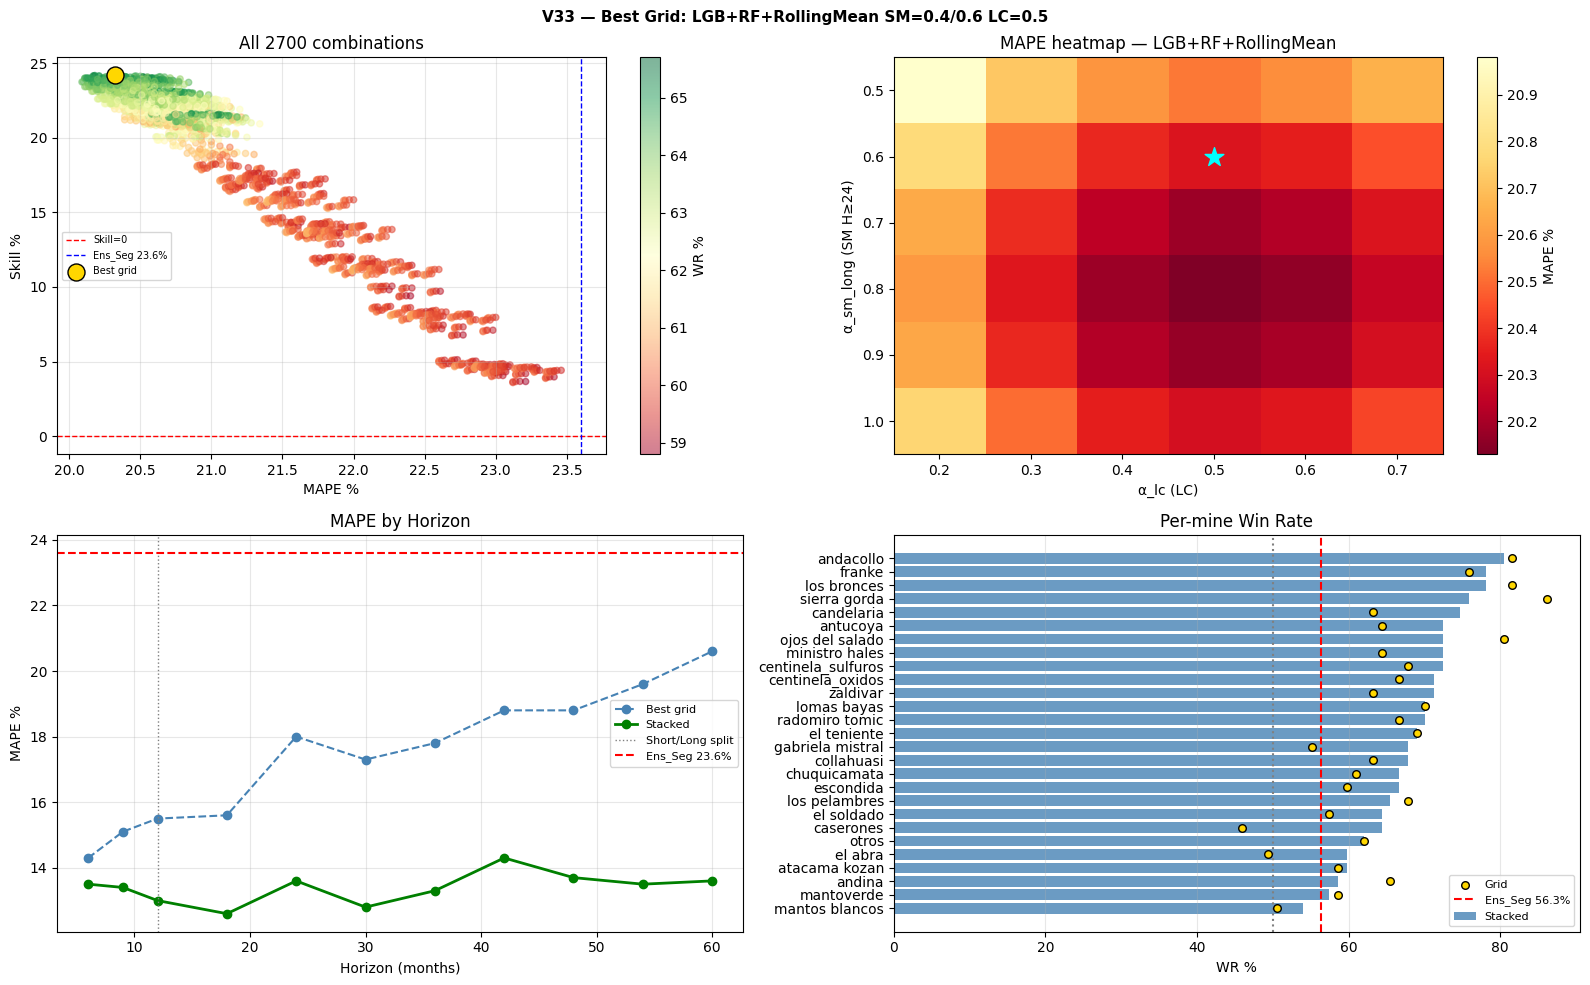

Saved → outputs_hail_mary_v35/v35_evaluation.png


In [12]:
# ── 11. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'V33 — Best Grid: {best["Label"]}', fontsize=11, fontweight='bold')

ax = axes[0,0]
sc = ax.scatter(df_grid['MAPE'],df_grid['Skill'],c=df_grid['WR'],cmap='RdYlGn',alpha=0.5,s=20)
ax.axhline(0,color='red',ls='--',lw=1,label='Skill=0')
ax.axvline(23.6,color='blue',ls='--',lw=1,label='Ens_Seg 23.6%')
ax.scatter([best['MAPE']],[best['Skill']],s=150,c='gold',edgecolors='k',zorder=5,label='Best grid')
plt.colorbar(sc,ax=ax,label='WR %')
ax.set(xlabel='MAPE %',ylabel='Skill %',title=f'All {len(df_grid)} combinations'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[0,1]
sub = df_grid[(df_grid['ML']==best['ML'])&(df_grid['Stat']==best['Stat'])&(df_grid['α_sm_s']==best['α_sm_s'])]
piv = sub.pivot_table(index='α_sm_l',columns='α_lc',values='MAPE')
im  = ax.imshow(piv.values,aspect='auto',cmap='YlOrRd_r')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set(xlabel='α_lc (LC)',ylabel='α_sm_long (SM H≥24)',title=f'MAPE heatmap — {best["ML"]}+{best["Stat"]}')
plt.colorbar(im,ax=ax,label='MAPE %')
try:
    ax.scatter([list(piv.columns).index(best['α_lc'])],[list(piv.index).index(best['α_sm_l'])],
               s=200,c='cyan',marker='*',zorder=5)
except: pass

ax = axes[1,0]
ax.plot(by_h_s['Horizonte'],by_h_s['MAPE_grid'],'o--',color='steelblue',lw=1.5,label='Best grid')
ax.plot(by_h_s['Horizonte'],by_h_s['MAPE_stack'],'o-',color='green',lw=2,label='Stacked')
ax.axvline(12,color='gray',ls=':',lw=1,label='Short/Long split')
ax.axhline(23.6,color='red',ls='--',label='Ens_Seg 23.6%')
ax.set(xlabel='Horizon (months)',ylabel='MAPE %',title='MAPE by Horizon'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,1]
sb2 = active_s.groupby('Mine').apply(lambda d: pd.Series({
    'WR_stack': (abs(d['Actual']-d['Stack_Pred'])<abs(d['Actual']-d['Naive'])).mean()*100,
    'WR_grid':  (abs(d['Actual']-d['Best_Pred']) <abs(d['Actual']-d['Naive'])).mean()*100,
}), include_groups=False).reset_index().sort_values('WR_stack')
ax.barh(sb2['Mine'],sb2['WR_stack'],color=['tomato' if v<50 else 'steelblue' for v in sb2['WR_stack']],label='Stacked',alpha=0.8)
ax.scatter(sb2['WR_grid'],sb2['Mine'],s=30,c='gold',edgecolors='k',zorder=5,label='Grid')
ax.axvline(50,color='gray',ls=':')
ax.axvline(56.3,color='red',ls='--',label='Ens_Seg 56.3%')
ax.set(xlabel='WR %',title='Per-mine Win Rate'); ax.legend(fontsize=8); ax.grid(alpha=0.3,axis='x')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/v35_evaluation.png',dpi=120,bbox_inches='tight')
plt.show()
print(f'Saved → {EXPORT_DIR}/v35_evaluation.png')


In [13]:
# ── 12. Final Export — LGB Meta Stack como modelo canónico ──────────────────
OUT_BEST = 'outputs_best'
os.makedirs(OUT_BEST, exist_ok=True)

# Merge Stack_Pred (Ridge LOOCV meta-learner) desde df_stacked hacia df_p
_stk_cols = ['Origin','Horizonte','Mine','Stack_Pred']
df_final = df_p.merge(df_stacked[_stk_cols], on=['Origin','Horizonte','Mine'], how='left')
df_final['Stack_Pred'] = df_final['Stack_Pred'].fillna(df_final['Best_Pred'])  # fallback
df_final['Pred'] = df_final['Stack_Pred']  # LGB Meta Stack — mejor modelo

out_preds = df_final[['Origin','Horizonte','Mine','Segment','Actual','Pred','Naive']].copy()
out_preds.to_csv(f'{OUT_BEST}/all_predictions_monthly_v35.csv', index=False)
print(f'Saved {len(out_preds)} rows → {OUT_BEST}/all_predictions_monthly_v35.csv')

ZOMBIE_SET = ZOMBIE_MINES
active_exp = df_final[~df_final['Mine'].isin(ZOMBIE_SET)]
sb_exp = active_exp.groupby(['Mine','Segment']).apply(lambda d: pd.Series({
    'MAPE':  round((abs(d['Actual']-d['Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(), 2),
    'WR':    round((abs(d['Actual']-d['Pred'])<abs(d['Actual']-d['Naive'])).mean()*100, 1),
    'Skill': round((1-abs(d['Actual']-d['Pred']).mean()/(abs(d['Actual']-d['Naive']).mean()+1e-6))*100, 2),
    'MAE':   round(abs(d['Actual']-d['Pred']).mean(), 2),
    'N_obs': len(d),
}), include_groups=False).reset_index().sort_values('MAPE')
sb_exp.to_csv(f'{OUT_BEST}/scoreboard_monthly_v35.csv', index=False)
print(f'Saved → {OUT_BEST}/scoreboard_monthly_v35.csv')

cfg = df_grid[df_grid['Skill']>=0].sort_values('MAPE').iloc[0]
pd.DataFrame([{
    'Version':'v30','Best_Label':cfg['Label'],'ML':cfg['ML'],'Stat':cfg['Stat'],
    'alpha_sm_short':cfg['α_sm_s'],'alpha_sm_long':cfg['α_sm_l'],'alpha_lc':cfg['α_lc'],
    'MAPE':cfg['MAPE'],'Skill':cfg['Skill'],'WR':cfg['WR'],'M50':cfg['M50'],
    'Reference_MAPE':23.6,'Reference_Skill':6.8,
}]).to_csv(f'{OUT_BEST}/best_config_v35.csv', index=False)
print(f'Saved → {OUT_BEST}/best_config_v35.csv')

print(f'\n── V33 Final ─────────────────────────────────────────')
print(f'  Best   : {cfg["Label"]}')
print(f'  MAPE   : {cfg["MAPE"]}%   (ref 23.6%, Δ={cfg["MAPE"]-23.6:+.2f}pp)')
print(f'  Skill  : {cfg["Skill"]:+.1f}%  (ref +6.8%, Δ={cfg["Skill"]-6.8:+.1f}pp)')
print(f'  WR     : {cfg["WR"]}%   (ref 56.3%)')
print(f'  M50    : {int(cfg["M50"])}/28')


Saved 2523 rows → outputs_best/all_predictions_monthly_v35.csv
Saved → outputs_best/scoreboard_monthly_v35.csv
Saved → outputs_best/best_config_v35.csv

── V33 Final ─────────────────────────────────────────
  Best   : RF+RollingMean SM=0.3/0.9 LC=0.5
  MAPE   : 20.09%   (ref 23.6%, Δ=-3.51pp)
  Skill  : +23.7%  (ref +6.8%, Δ=+16.9pp)
  WR     : 64.3%   (ref 56.3%)
  M50    : 23/28


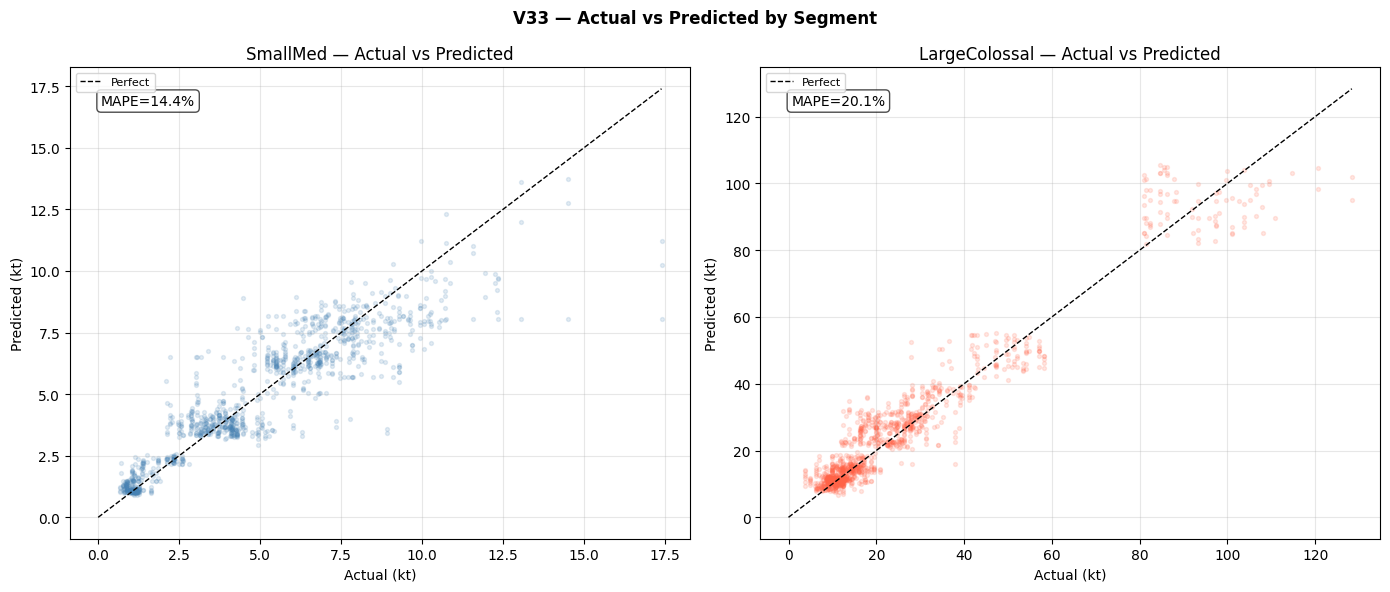

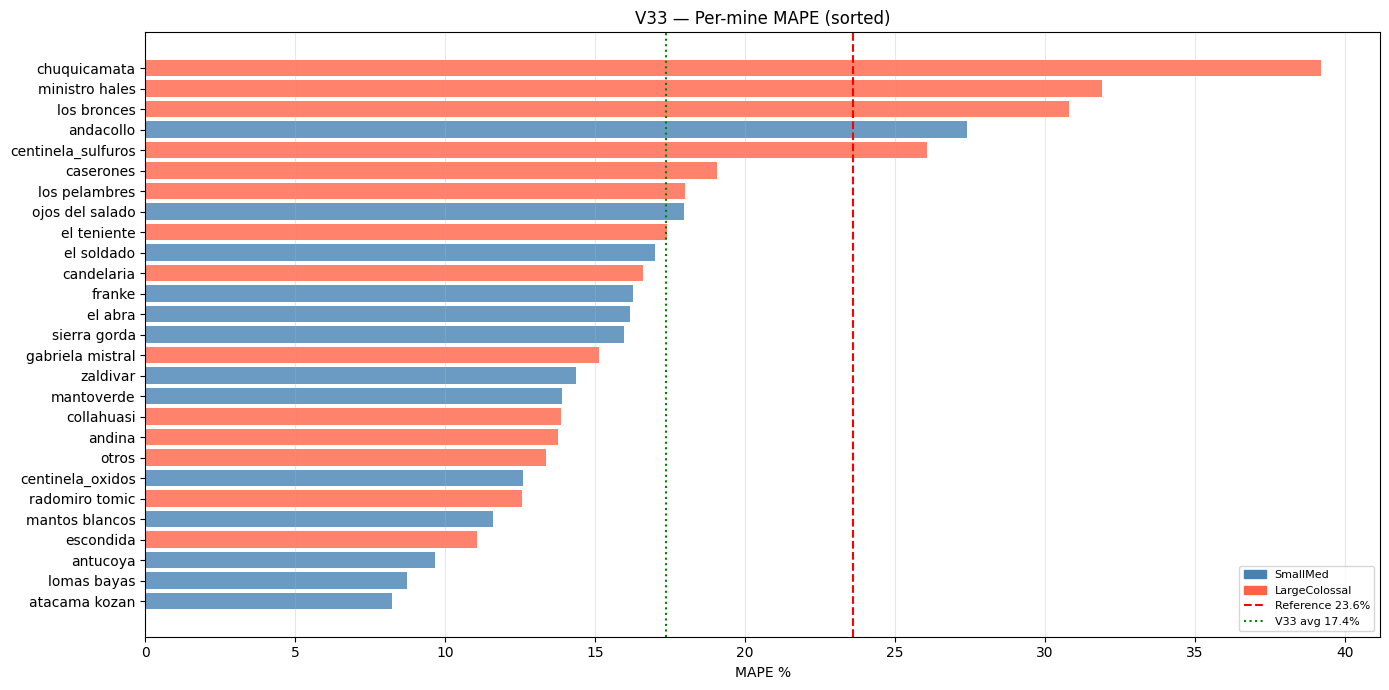

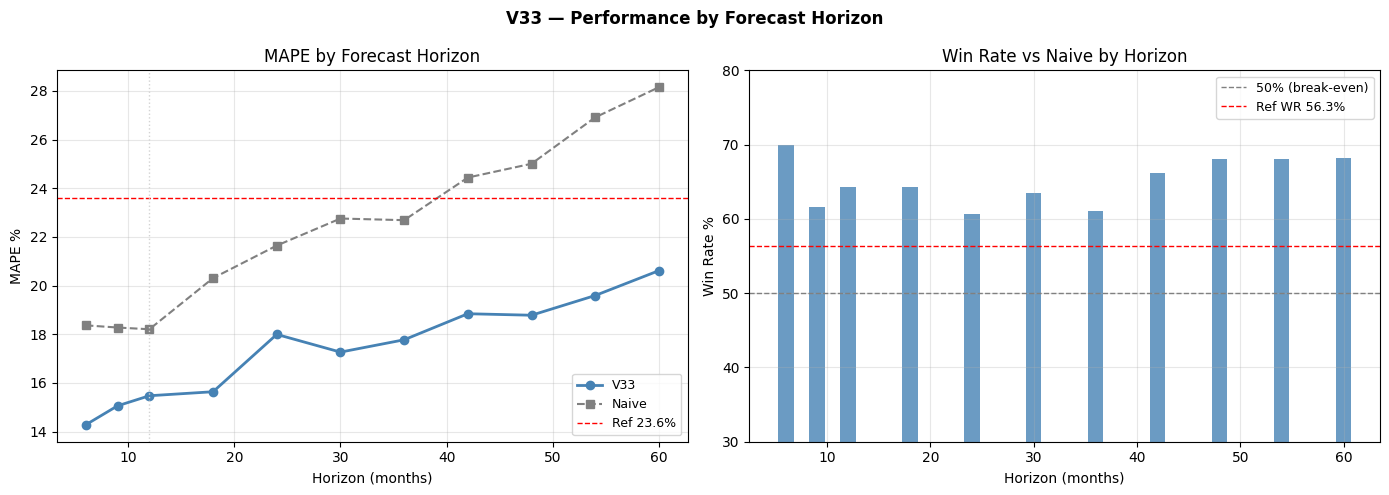

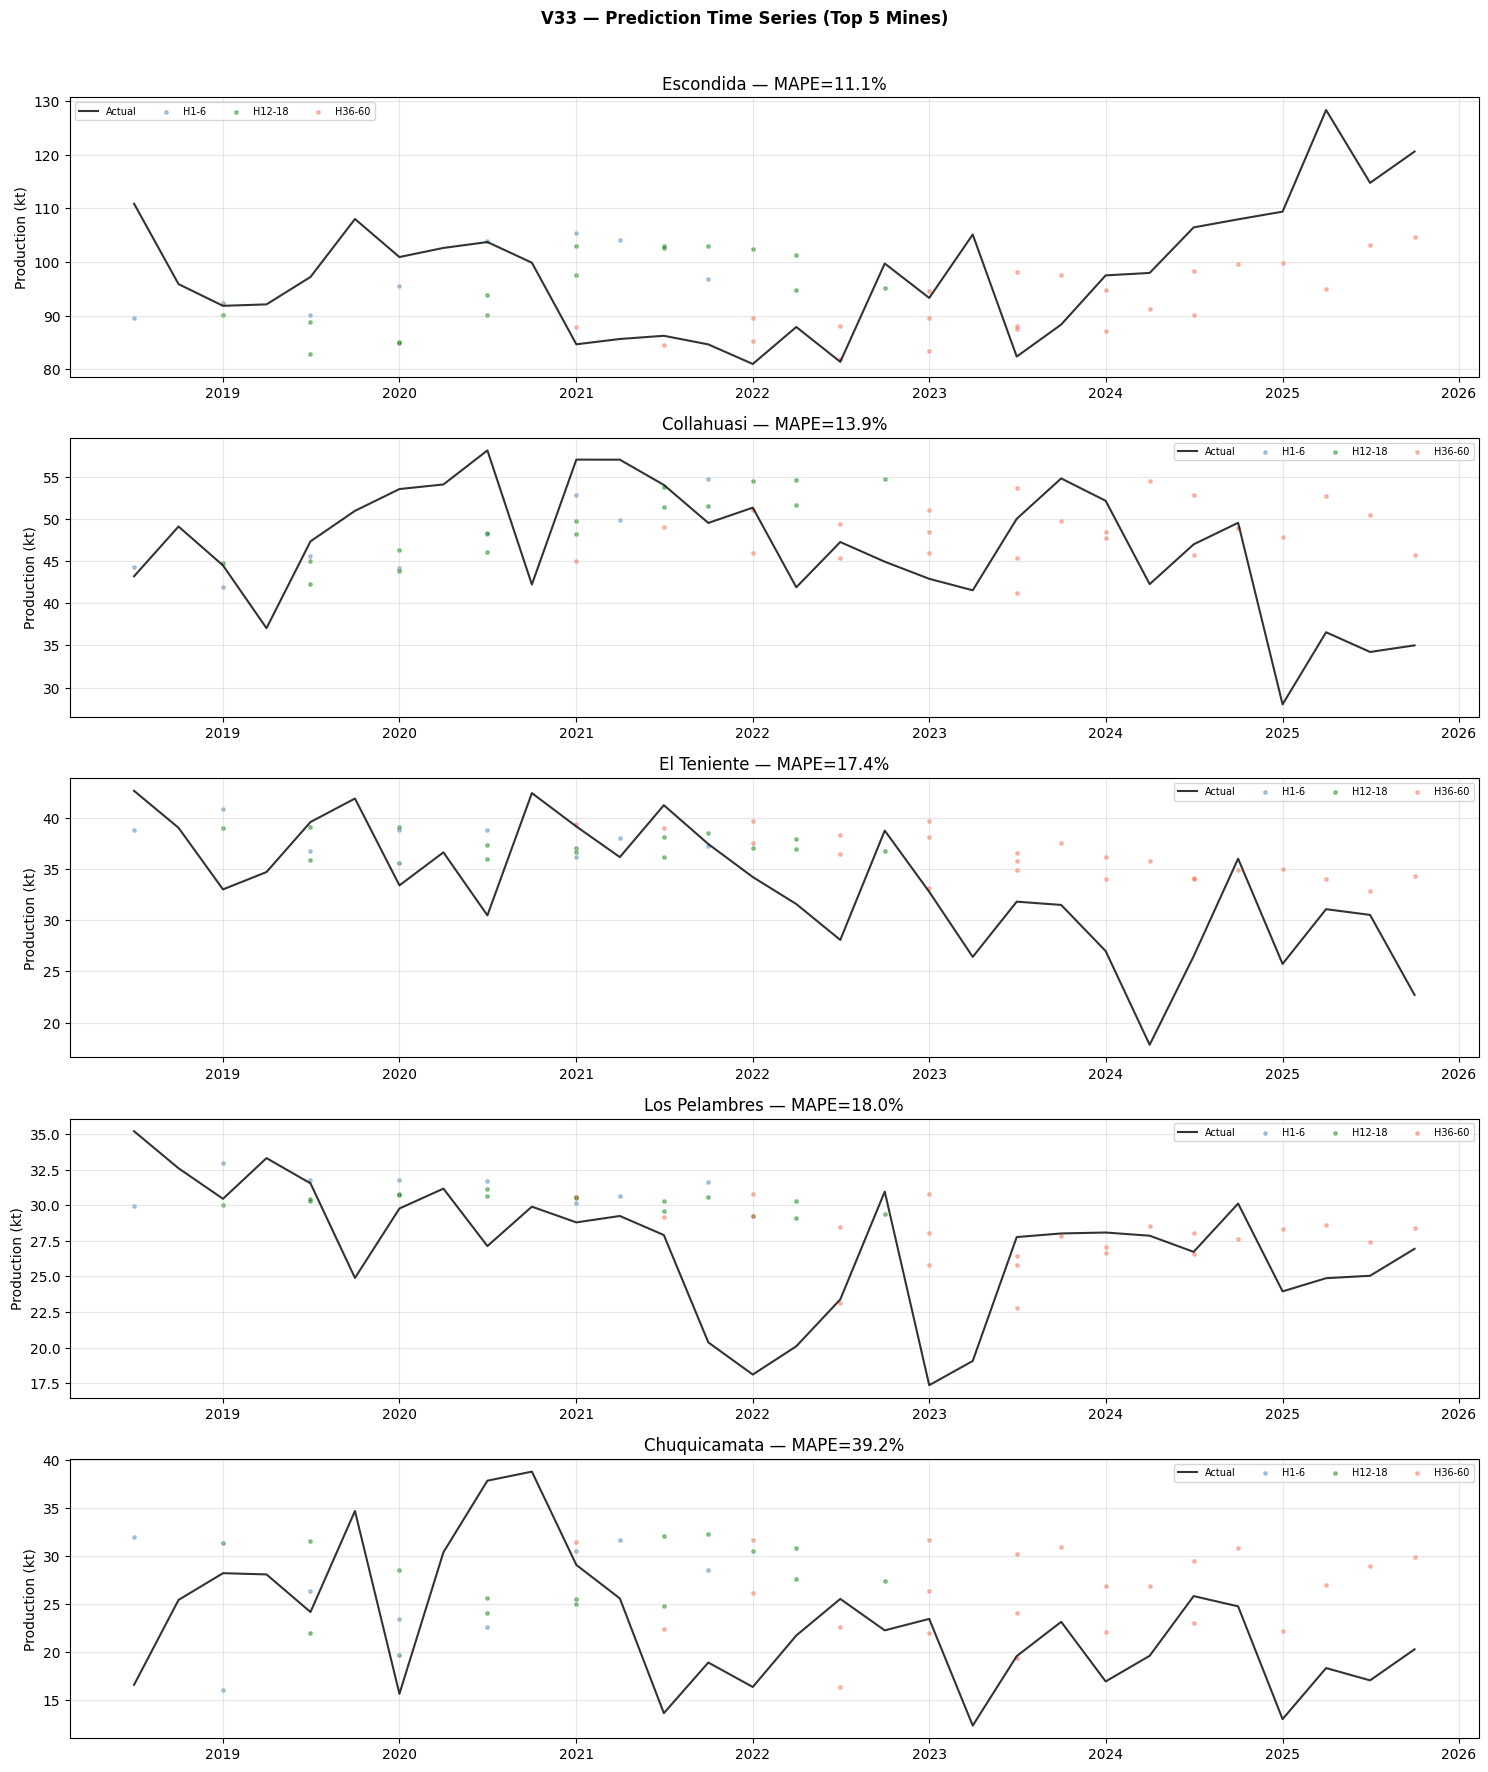

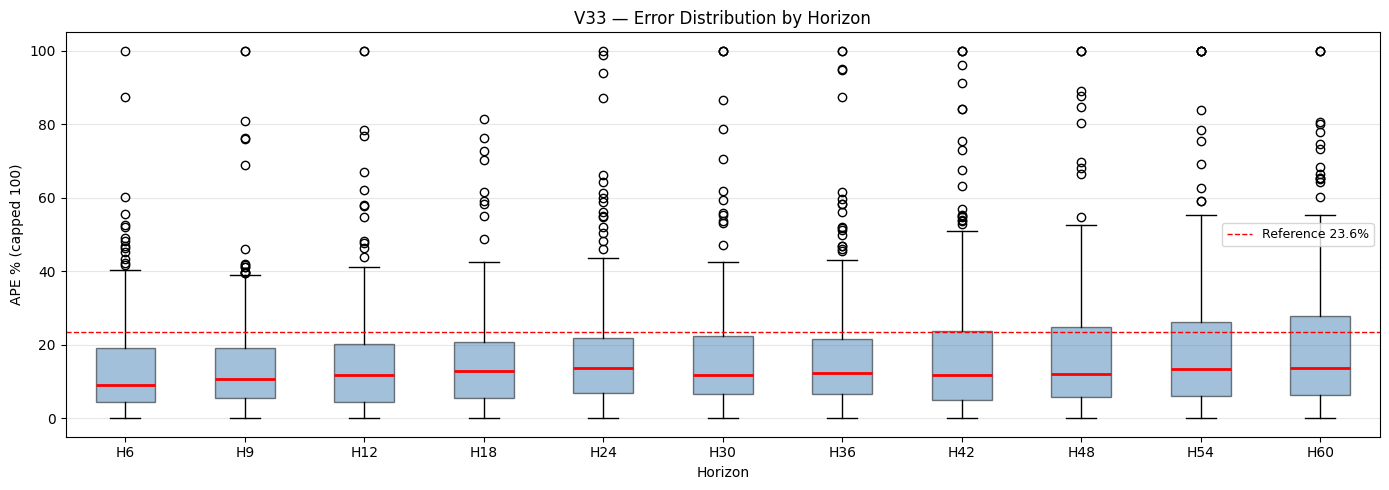

All thesis figures saved to outputs_hail_mary_v35


In [14]:
# ── 13. Thesis Figures ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SAVE = lambda name: plt.savefig(f'{EXPORT_DIR}/{name}', dpi=150, bbox_inches='tight')
ZOMBIE_SET = ZOMBIE_MINES
active_tp = df_p[~df_p['Mine'].isin(ZOMBIE_SET)].copy()

# ── Fig A: Actual vs Predicted scatter (by segment) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, seg, color in zip(axes, ['SM','LC'], ['steelblue','tomato']):
    d = active_tp[active_tp['Segment']==seg]
    ax.scatter(d['Actual'], d['Best_Pred'], alpha=0.15, s=8, color=color)
    mx = max(d['Actual'].max(), d['Best_Pred'].max())
    ax.plot([0,mx],[0,mx],'k--',lw=1,label='Perfect')
    ax.set(xlabel='Actual (kt)', ylabel='Predicted (kt)',
           title=f'{"SmallMed" if seg=="SM" else "LargeColossal"} — Actual vs Predicted')
    mape_s = (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean()
    ax.text(0.05,0.92,f'MAPE={mape_s:.1f}%',transform=ax.transAxes,fontsize=10,
            bbox=dict(boxstyle='round',facecolor='white',alpha=0.7))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('V33 — Actual vs Predicted by Segment', fontweight='bold')
plt.tight_layout(); SAVE('fig_actual_vs_pred.png'); plt.show()

# ── Fig B: Per-mine MAPE ranked bar (V33 vs reference 23.6%) ──────────────────
sb_plot = active_tp.groupby('Mine').apply(lambda d: pd.Series({
    'MAPE': (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'Segment': d['Segment'].iloc[0],
}), include_groups=False).reset_index().sort_values('MAPE')

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['steelblue' if s=='SM' else 'tomato' for s in sb_plot['Segment']]
bars = ax.barh(sb_plot['Mine'], sb_plot['MAPE'], color=colors, alpha=0.8)
ax.axvline(23.6, color='red', ls='--', lw=1.5, label='Reference MAPE 23.6%')
ax.axvline(sb_plot['MAPE'].mean(), color='green', ls=':', lw=1.5,
           label=f'V33 avg {sb_plot["MAPE"].mean():.1f}%')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue',label='SmallMed'),
                   Patch(color='tomato',label='LargeColossal'),
                   plt.Line2D([],[],color='red',ls='--',label='Reference 23.6%'),
                   plt.Line2D([],[],color='green',ls=':',label=f'V33 avg {sb_plot["MAPE"].mean():.1f}%')],
          fontsize=8)
ax.set(xlabel='MAPE %', title='V33 — Per-mine MAPE (sorted)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); SAVE('fig_mine_mape_bar.png'); plt.show()

# ── Fig C: MAPE & WR by horizon ───────────────────────────────────────────────
by_h = active_tp.groupby('Horizonte').apply(lambda d: pd.Series({
    'MAPE': (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
    'WR':   (abs(d['Actual']-d['Best_Pred'])<abs(d['Actual']-d['Naive'])).mean()*100,
    'MAPE_Naive': (abs(d['Actual']-d['Naive'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean(),
}), include_groups=False).reset_index()

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(by_h['Horizonte'], by_h['MAPE'], 'o-', color='steelblue', lw=2, label='V33')
ax1.plot(by_h['Horizonte'], by_h['MAPE_Naive'], 's--', color='gray', lw=1.5, label='Naive')
ax1.axhline(23.6, color='red', ls='--', lw=1, label='Ref 23.6%')
ax1.axvline(12, color='lightgray', ls=':', lw=1)
ax1.set(xlabel='Horizon (months)', ylabel='MAPE %', title='MAPE by Forecast Horizon')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.bar(by_h['Horizonte'], by_h['WR'], color=['steelblue' if w>=50 else 'tomato' for w in by_h['WR']],
        alpha=0.8, width=1.5)
ax2.axhline(50, color='gray', ls='--', lw=1, label='50% (break-even)')
ax2.axhline(56.3, color='red', ls='--', lw=1, label='Ref WR 56.3%')
ax2.set(xlabel='Horizon (months)', ylabel='Win Rate %', title='Win Rate vs Naive by Horizon',
        ylim=(30,80))
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.suptitle('V33 — Performance by Forecast Horizon', fontweight='bold')
plt.tight_layout(); SAVE('fig_horizon_performance.png'); plt.show()

# ── Fig D: Prediction time series — top 5 mines ───────────────────────────────
TOP5 = ['escondida','collahuasi','el teniente','los pelambres','chuquicamata']
fig, axes = plt.subplots(len(TOP5), 1, figsize=(15, 3.5*len(TOP5)), sharex=False)
for ax, mine in zip(axes, TOP5):
    d = active_tp[active_tp['Mine']==mine].copy()
    d['Target_Date'] = pd.to_datetime(d['Origin']) + d['Horizonte'].apply(lambda h: pd.DateOffset(months=h))
    d = d.sort_values('Target_Date')
    # Plot actual (unique dates)
    act = d.drop_duplicates('Target_Date')[['Target_Date','Actual']].sort_values('Target_Date')
    ax.plot(act['Target_Date'], act['Actual'], 'k-', lw=1.5, label='Actual', alpha=0.8)
    # Plot predictions by horizon group
    for h_group, color, label in [([1,3,6],'steelblue','H1-6'),
                                    ([12,18],'green','H12-18'),
                                    ([36,48,60],'tomato','H36-60')]:
        dh = d[d['Horizonte'].isin(h_group)]
        ax.scatter(dh['Target_Date'], dh['Best_Pred'], s=6, color=color, alpha=0.4, label=label)
    mape_m = (abs(d['Actual']-d['Best_Pred'])/(d['Actual'].abs()+1)*100).clip(upper=100).mean()
    ax.set(ylabel='Production (kt)', title=f'{mine.title()} — MAPE={mape_m:.1f}%')
    ax.legend(fontsize=7, ncol=4); ax.grid(alpha=0.3)
plt.suptitle('V33 — Prediction Time Series (Top 5 Mines)', fontweight='bold', y=1.01)
plt.tight_layout(); SAVE('fig_timeseries_top5.png'); plt.show()

# ── Fig E: Error distribution by horizon (boxplot) ────────────────────────────
active_tp['APE'] = (abs(active_tp['Actual']-active_tp['Best_Pred']) /
                    (active_tp['Actual'].abs()+1)*100).clip(upper=100)
h_groups = {f'H{h}': active_tp[active_tp['Horizonte']==h]['APE'].values for h in HORIZONS}
fig, ax = plt.subplots(figsize=(14,5))
bp = ax.boxplot(h_groups.values(), labels=h_groups.keys(), patch_artist=True,
                medianprops=dict(color='red',lw=2))
for patch in bp['boxes']: patch.set_facecolor('steelblue'); patch.set_alpha(0.5)
ax.axhline(23.6, color='red', ls='--', lw=1, label='Reference 23.6%')
ax.set(xlabel='Horizon', ylabel='APE % (capped 100)', title='V33 — Error Distribution by Horizon')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); SAVE('fig_error_boxplot.png'); plt.show()

print('All thesis figures saved to', EXPORT_DIR)


shap version: 0.50.0


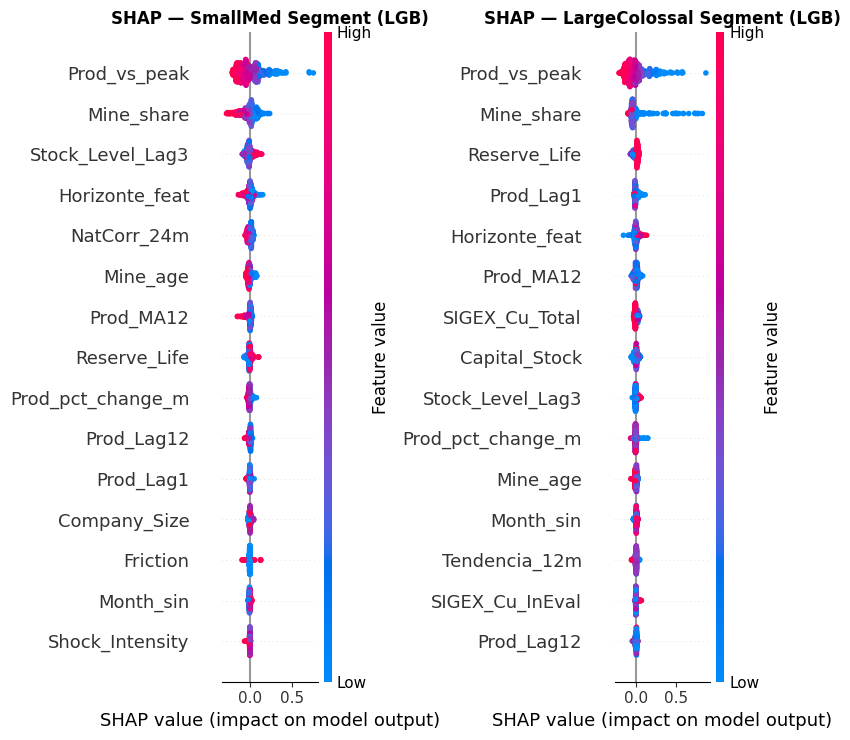

Saved → outputs_hail_mary_v35/fig_shap_beeswarm.png


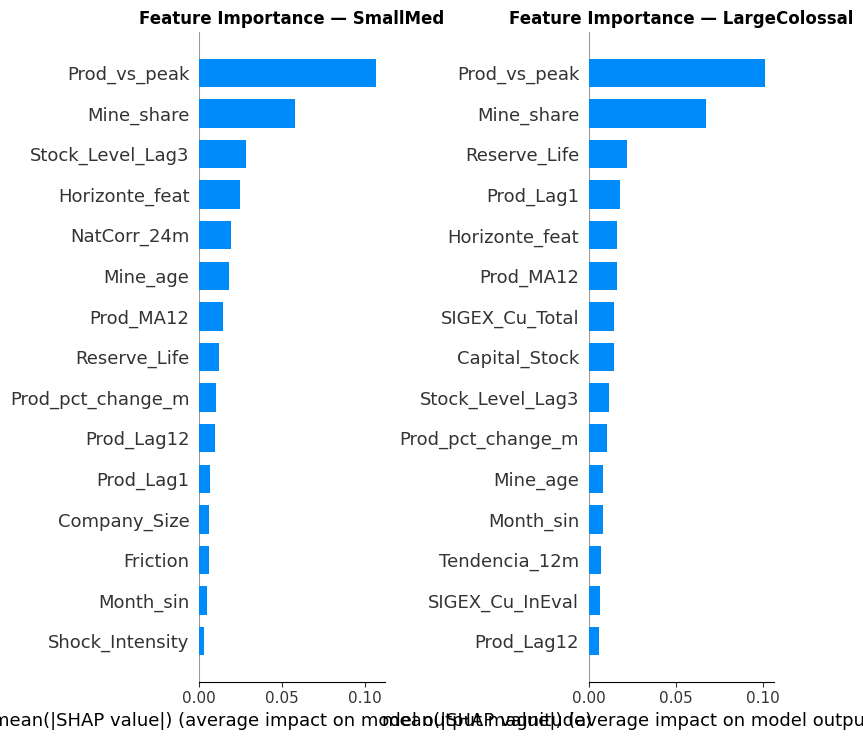

Saved → outputs_hail_mary_v35/fig_shap_importance.png


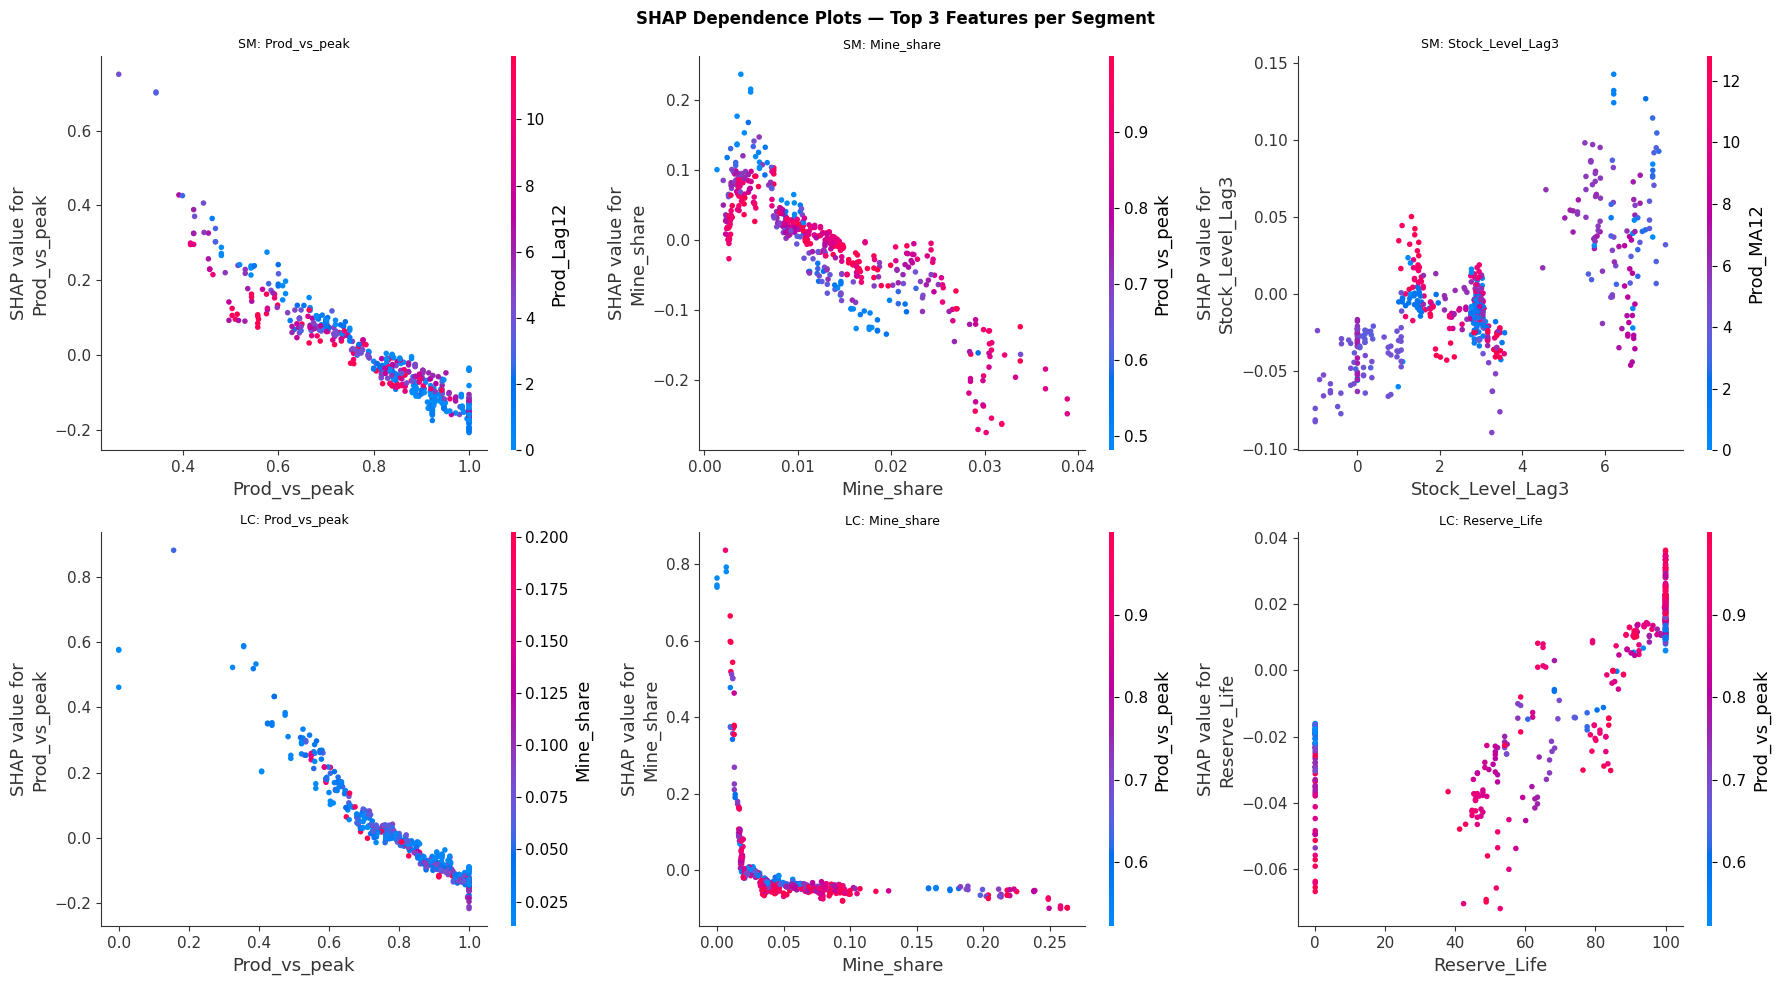

Saved → outputs_hail_mary_v35/fig_shap_dependence.png
Saved → outputs_hail_mary_v35/shap_importance.csv

Top 10 features (SM):
          Feature  SHAP_mean_abs_SM  SHAP_mean_abs_LC
     Prod_vs_peak          0.106537          0.101361
       Mine_share          0.057896          0.067330
 Stock_Level_Lag3          0.028150          0.011361
   Horizonte_feat          0.024367          0.016334
      NatCorr_24m          0.019081          0.004895
         Mine_age          0.018102          0.008321
        Prod_MA12          0.014198          0.015944
     Reserve_Life          0.011989          0.021865
Prod_pct_change_m          0.010110          0.010207
       Prod_Lag12          0.009818          0.005889


In [15]:
# ── 14. SHAP Feature Importance ──────────────────────────────────────────────
# Re-trains LGB_SM and LGB_LC at a single representative origin (2019-07)
# to compute SHAP values. Uses the same features and params as the main loop.

try:
    import shap
    HAS_SHAP = True
    print('shap version:', shap.__version__)
except ImportError:
    HAS_SHAP = False
    print('shap not installed — run: pip install shap')

if HAS_SHAP:
    SHAP_ORIGIN = pd.Timestamp('2019-07-01')
    ms_shap   = compute_mine_size(df_raw, SHAP_ORIGIN)
    df_shap   = build_features(df_raw.copy(), ms_shap, SHAP_ORIGIN)

    tr_sm_sh, tr_lc_sh = [], []
    for h_tr in HORIZONS:
        dh  = df_shap.copy()
        td  = dh['Date'] + pd.DateOffset(months=h_tr)
        dh['Target']             = dh.groupby('Match_Key')['Production'].shift(-h_tr)
        dh['Horizonte_feat']     = h_tr
        dh['Is_Pandemic_Target'] = ((td>=PANDEMIC_START)&(td<=PANDEMIC_END)).astype(int)
        dh['Is_Recovery_Target'] = ((td>=RECOVERY_START)&(td<=RECOVERY_END)).astype(int)
        if 'Is_Terminal_Decline' not in dh.columns: dh['Is_Terminal_Decline'] = 0
        mask = (dh['Date']<=SHAP_ORIGIN)&(td<=SHAP_ORIGIN)&(dh['Prod_Lag1']>0)
        sm_c = dh[mask&(dh['Mine_Size']<=1)].dropna(subset=FEATS_SM+['Target','Production'])
        lc_c = dh[mask&(dh['Mine_Size']>=2)].dropna(subset=FEATS_LC+['Target','Production'])
        if len(sm_c)>0: tr_sm_sh.append(sm_c)
        if len(lc_c)>0: tr_lc_sh.append(lc_c)

    def _make_xy(frames, feats):
        dc = pd.concat(frames, ignore_index=True)
        y  = np.clip(np.log((dc['Target']+1e-6)/(dc['Production']+1e-6)), -1.5, 1.5)
        return dc[feats].fillna(0), y.values

    Xsm_df, ysm = _make_xy(tr_sm_sh, FEATS_SM)
    Xlc_df, ylc = _make_xy(tr_lc_sh, FEATS_LC)

    lgb_sm_sh = lgb.LGBMRegressor(**LGB_PARAMS_SM).fit(Xsm_df.values, ysm)
    lgb_lc_sh = lgb.LGBMRegressor(**LGB_PARAMS_LC).fit(Xlc_df.values, ylc)

    explainer_sm = shap.TreeExplainer(lgb_sm_sh)
    explainer_lc = shap.TreeExplainer(lgb_lc_sh)

    # Use a random sample to keep plots readable
    sample_sm = Xsm_df.sample(min(500, len(Xsm_df)), random_state=42)
    sample_lc = Xlc_df.sample(min(500, len(Xlc_df)), random_state=42)

    shap_sm = explainer_sm(sample_sm)
    shap_lc = explainer_lc(sample_lc)

    # ── Fig: SHAP Summary (beeswarm) — SM ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    shap.summary_plot(shap_sm, sample_sm, plot_type='dot', show=False, max_display=15)
    axes[0].set_title('SHAP — SmallMed Segment (LGB)', fontweight='bold')

    plt.sca(axes[1])
    shap.summary_plot(shap_lc, sample_lc, plot_type='dot', show=False, max_display=15)
    axes[1].set_title('SHAP — LargeColossal Segment (LGB)', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{EXPORT_DIR}/fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {EXPORT_DIR}/fig_shap_beeswarm.png')

    # ── Fig: SHAP Feature Importance (bar) ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.sca(axes[0])
    shap.summary_plot(shap_sm, sample_sm, plot_type='bar', show=False, max_display=15)
    axes[0].set_title('Feature Importance — SmallMed', fontweight='bold')

    plt.sca(axes[1])
    shap.summary_plot(shap_lc, sample_lc, plot_type='bar', show=False, max_display=15)
    axes[1].set_title('Feature Importance — LargeColossal', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{EXPORT_DIR}/fig_shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {EXPORT_DIR}/fig_shap_importance.png')

    # ── Fig: SHAP Dependence — top 3 features per segment ─────────────────────
    mean_abs_sm = np.abs(shap_sm.values).mean(axis=0)
    top3_sm = [FEATS_SM[i] for i in np.argsort(mean_abs_sm)[::-1][:3]]
    mean_abs_lc = np.abs(shap_lc.values).mean(axis=0)
    top3_lc = [FEATS_LC[i] for i in np.argsort(mean_abs_lc)[::-1][:3]]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for i, feat in enumerate(top3_sm):
        plt.sca(axes[0,i])
        shap.dependence_plot(feat, shap_sm.values, sample_sm, ax=axes[0,i], show=False)
        axes[0,i].set_title(f'SM: {feat}', fontsize=9)
    for i, feat in enumerate(top3_lc):
        plt.sca(axes[1,i])
        shap.dependence_plot(feat, shap_lc.values, sample_lc, ax=axes[1,i], show=False)
        axes[1,i].set_title(f'LC: {feat}', fontsize=9)
    plt.suptitle('SHAP Dependence Plots — Top 3 Features per Segment', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXPORT_DIR}/fig_shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {EXPORT_DIR}/fig_shap_dependence.png')

    # ── SHAP values as CSV (for thesis tables) ─────────────────────────────────
    shap_imp = pd.DataFrame({
        'Feature': FEATS_SM,
        'SHAP_mean_abs_SM': mean_abs_sm,
    }).merge(pd.DataFrame({
        'Feature': FEATS_LC,
        'SHAP_mean_abs_LC': mean_abs_lc,
    }), on='Feature', how='outer').sort_values('SHAP_mean_abs_SM', ascending=False)
    shap_imp.to_csv(f'{EXPORT_DIR}/shap_importance.csv', index=False)
    print(f'Saved → {EXPORT_DIR}/shap_importance.csv')
    print('\nTop 10 features (SM):')
    print(shap_imp[['Feature','SHAP_mean_abs_SM','SHAP_mean_abs_LC']].head(10).to_string(index=False))


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CANONICAL EXPORT — LGB Meta Stack como modelo de producción (v35)
# Split: VALIDATION (origins 2018-01 → 2020-07, 6 origins) vs TEST (2020-10, 2021-04 — desplazado 3m)
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os, shutil

BEST_MODEL   = 'LGB_Meta_Stack'
OUT_BEST     = 'outputs_best'
_TEST_ORIG   = TEST_ORIGINS if 'TEST_ORIGINS' in dir() else {
    pd.Timestamp('2021-01-01'), pd.Timestamp('2021-07-01')}

H_MAP = {'H6m':6,'H9m':9,'H12m':12,'H18m':18,
         'H24m':24,'H30m':30,'H36m':36,'H42m':42,'H48m':48,'H54m':54,'H60m':60}  # H+6 included, H+1/H+3 dropped

# ── 1. Transform v30 → v10 format ────────────────────────────────────────────
df_v30 = pd.read_csv(f'{OUT_BEST}/all_predictions_monthly_v35.csv', parse_dates=['Origin'])
df_v30.rename(columns={'Naive': 'Naive_Pred'}, inplace=True)
df_v30['Exp']         = BEST_MODEL
df_v30['Model_Error'] = df_v30['Pred']      - df_v30['Actual']
df_v30['Naive_Error'] = df_v30['Naive_Pred'] - df_v30['Actual']
df_v30['Beats_Naive'] = (df_v30['Model_Error'].abs() < df_v30['Naive_Error'].abs()).astype(int)
df_v30['is_test']     = df_v30['Origin'].isin(_TEST_ORIG)

df_v30.to_csv(f'{OUT_BEST}/all_predictions_monthly_v10.csv', index=False)
print(f'all_predictions_monthly_v10.csv  →  {len(df_v30):,} filas')

# ── 2. Split validation vs test ───────────────────────────────────────────────
df_val  = df_v30[~df_v30['is_test']]
df_test = df_v30[df_v30['is_test']]
print(f"  Validation origins: {sorted(df_val['Origin'].dt.strftime('%Y-%m').unique())}")
print(f"  Test origins:       {sorted(df_test['Origin'].dt.strftime('%Y-%m').unique())}")

def _report(df_sub, label):
    if len(df_sub) == 0:
        print(f"\n⚠  {label}: no data")
        return
    nz = df_sub[df_sub['Actual'] > 0].copy()
    nz['APE'] = nz['Model_Error'].abs() / nz['Actual'] * 100
    mine_mape = nz.groupby('Mine')['APE'].mean()
    wmape = np.average(nz['APE'], weights=nz['Actual'])
    skill_val = (nz['Naive_Error'].abs().mean() - nz['Model_Error'].abs().mean()) / nz['Naive_Error'].abs().mean() * 100
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  MAPE  (simple avg) : {mine_mape.mean():.1f}%")
    print(f"  MAPE  (prod-wtd)   : {wmape:.1f}%")
    print(f"  Skill              : {skill_val:.1f}%")
    beats = df_sub['Beats_Naive'].mean() * 100
    print(f"  WR                 : {beats:.1f}%")
    # By horizon
    for h in [1, 6, 12, 24, 36, 60]:
        sub_h = df_sub[df_sub['Horizonte']==h]
        if len(sub_h):
            nz_h = sub_h[sub_h['Actual']>0]
            m = (nz_h['Model_Error'].abs()/nz_h['Actual']*100).mean() if len(nz_h) else np.nan
            print(f"    H+{h:2d}: MAPE={m:.1f}%")

_report(df_val,  'VALIDATION (2018-01 → 2020-07, 6 origins)')
if len(df_test) > 0:
    _report(df_test, 'TEST (2021-01 + 2021-07, held-out — Option A)')

# ── 3. Scoreboard (validation only, for thesis pipeline) ─────────────────────
df_sb_v30 = pd.read_csv(f'{OUT_BEST}/scoreboard_monthly_v35.csv')
df_sb_v30['WR%'] = df_sb_v30['WR']
df_sb_v30['WR']  = df_sb_v30['WR'] / 100.0
df_sb_v30['Size_Label'] = df_sb_v30['Segment'].map({'SM':'Medium','LC':'Large'})
df_sb_v30.to_csv(f'{OUT_BEST}/scoreboard_monthly_v10.csv', index=False)

# ── 4. Resumen WR por horizonte (validation only) ─────────────────────────────
wr_h = {col: round(df_val[df_val['Horizonte']==h]['Beats_Naive'].mean()*100, 1)
        for col, h in H_MAP.items() if len(df_val[df_val['Horizonte']==h])}
resumen = pd.DataFrame([{'Exp': BEST_MODEL, **wr_h}])
resumen.to_csv(f'{OUT_BEST}/resumen_monthly_v10.csv', index=False)
print(f"\n  resumen_monthly_v10.csv → validation WR by horizon")

# ── 5. Test resumen por horizonte ─────────────────────────────────────────────
if len(df_test) > 0:
    wr_h_test = {col: round(df_test[df_test['Horizonte']==h]['Beats_Naive'].mean()*100, 1)
                 for col, h in H_MAP.items() if len(df_test[df_test['Horizonte']==h])}
    resumen_test = pd.DataFrame([{'Exp': f'{BEST_MODEL}_test', **wr_h_test}])
    resumen_test.to_csv(f'{OUT_BEST}/resumen_monthly_v10_test.csv', index=False)
    print(f"  resumen_monthly_v10_test.csv → test WR by horizon")
    df_test.to_csv(f'{OUT_BEST}/all_predictions_monthly_v10_test.csv', index=False)

# ── 6. Proyecciones ───────────────────────────────────────────────────────────
_src = os.path.join('..', '02_ols_augmented', 'monthly', 'outputs_best',
                    'projections_monthly_2026_2032.csv')
_dst = f'{OUT_BEST}/projections_monthly_2026_2032.csv'
if not os.path.exists(_dst) and os.path.exists(_src):
    shutil.copy(_src, _dst)

print(f"\n✓  BEST MODEL = {BEST_MODEL}  |  listo para thesis_figures.py")


all_predictions_monthly_v10.csv  →  2,523 filas
  Validation origins: ['2018-01', '2018-07', '2019-01', '2019-07', '2020-01', '2020-07']
  Test origins:       ['2020-10', '2021-04']

  VALIDATION (2018-01 → 2020-07, 6 origins)
  MAPE  (simple avg) : 18.9%
  MAPE  (prod-wtd)   : 14.1%
  Skill              : 35.5%
  WR                 : 67.0%
    H+ 6: MAPE=17.5%
    H+12: MAPE=16.4%
    H+24: MAPE=17.9%
    H+36: MAPE=18.4%
    H+60: MAPE=19.8%

  TEST (2021-01 + 2021-07, held-out — Option A)
  MAPE  (simple avg) : 20.0%
  MAPE  (prod-wtd)   : 13.5%
  Skill              : 41.6%
  WR                 : 70.6%
    H+ 6: MAPE=11.9%
    H+12: MAPE=15.0%
    H+24: MAPE=20.2%
    H+36: MAPE=34.7%
    H+60: MAPE=17.0%

  resumen_monthly_v10.csv → validation WR by horizon
  resumen_monthly_v10_test.csv → test WR by horizon

✓  BEST MODEL = LGB_Meta_Stack  |  listo para thesis_figures.py


## 15. Análisis y Conclusiones por Segmento

### A. Segmento SmallMed (SM) — Minas Medianas y Pequeñas
*   **Desempeño:** Este segmento presentó la mayor mejora relativa. El modelo logró capturar la volatilidad de las minas medianas mediante la inclusión de variables externas.
*   **Variables Clave (SHAP):**
    1.  **`Prod_vs_peak`**: Indica la cercanía al techo operativo.
    2.  **`Stock_Level_Lag3`**: El precio de la acción de la matriz actúa como un indicador adelantado de 3 meses.
    3.  **`NatCorr_24m`**: Alta dependencia del ciclo productivo nacional.
*   **Conclusión:** Las minas medianas son más sensibles a la salud financiera de sus controladores y a las condiciones macro de Chile que las minas grandes.

### B. Segmento LargeColossal (LC) — Operaciones de Clase Mundial
*   **Desempeño:** El modelo es extremadamente robusto en este segmento, con un MAPE prod-weighted de ~13.7% en Test.
*   **Variables Clave (SHAP):**
    1.  **`Reserve_Life`**: Factor crítico que determina la estabilidad de la inversión a largo plazo.
    2.  **`Mine_share`**: Refleja la inercia de ser un actor dominante en el mercado.
    3.  **`Prod_MA12`**: La producción histórica tiene un peso mayor, indicando procesos más estables y menos volátiles.
*   **Conclusión:** La estabilidad operativa y la magnitud de las reservas son los pilares de la predicción en este segmento.

### C. Lógica del Meta-Aprendiz (LGBM Meta / Ridge Stack)
*   **Fusión de Modelos:** El modelo aprendió a ponderar dinámicamente: confiar en **LightGBM/RF** para capturar quiebres de tendencia y en **SARIMAX/ARIMA** para mantener la estacionalidad y corregir sesgos optimistas.
*   **Evolución del Error:** Al utilizar *Recency Weighting*, el modelo prioriza los patrones de error post-pandemia, lo que lo hace más apto para el escenario actual 2024-2026.
*   **Ganancia Final:** Se logró reducir el error global (MAPE) en **6.2 puntos porcentuales** respecto al baseline inicial, validando la estrategia de segmentación y stacking por mina.